# Analyse Exploratoire des Données (EDA)
## Projet ValuSense — Système de Recommandation de Méthodes de Valorisation
### Phase 1 du CRISP-DM : Compréhension & Validation des Données

**Objectifs de ce notebook :**
1. Charger et vérifier l'intégrité de tous les datasets collectés
2. Valider la compatibilité des données avec notre problématique
3. Analyser la distribution de la variable cible (méthode de valorisation recommandée)
4. Vérifier la cohérence financière des règles expertes (asset → méthode)
5. Identifier les features discriminantes et les éventuels problèmes de qualité
6. Préparer un tableau de synthèse pour le rapport (Chapitre 3)

---
## 0. Imports et Configuration

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="viridis", font_scale=1.1)
plt.rcParams["figure.dpi"] = 150
plt.rcParams["figure.figsize"] = (12, 6)

# Créer le dossier pour les figures du rapport
os.makedirs("reports/figures", exist_ok=True)

# Chemin racine des données
DATA_ROOT = "data_valuation_project"

print("✅ Imports et configuration terminés.")

✅ Imports et configuration terminés.


---
## 1. Inventaire et Chargement des Données

Avant toute analyse, nous vérifions que **tous les fichiers** produits lors de la phase de collecte sont présents et lisibles. Chaque fichier correspond à une source de données identifiée dans notre pipeline.

In [3]:
# ── Dictionnaire complet des fichiers attendus ──────────────────────
expected_files = {
    # Catalogue principal
    "Catalogue instruments": f"{DATA_ROOT}/catalogs/full_instrument_catalog.csv",
    
    # Dataset labellisé (données d'entraînement)
    "Dataset labellisé": f"{DATA_ROOT}/processed/labeled_valuation_dataset.csv",
    
    # Données actions
    "Prix historiques actions": f"{DATA_ROOT}/raw/equities/equity_historical_prices.parquet",
    "Fondamentaux actions": f"{DATA_ROOT}/raw/equities/equity_fundamentals.parquet",
    
    # Données options
    "Chaînes d'options": f"{DATA_ROOT}/raw/options/options_chains_full.parquet",
    
    # Données obligataires
    "Métadonnées ETF obligataires": f"{DATA_ROOT}/raw/bonds/bond_etf_metadata.parquet",
    "Prix ETF obligataires": f"{DATA_ROOT}/raw/bonds/bond_etf_prices.parquet",
    "Courbe des taux (snapshot)": f"{DATA_ROOT}/raw/bonds/latest_yield_curve.csv",
    
    # Données macroéconomiques (FRED)
    "Taux souverains (FRED)": f"{DATA_ROOT}/raw/macro/fred_treasury_yields.parquet",
    "Taux d'intérêt (FRED)": f"{DATA_ROOT}/raw/macro/fred_interest_rates.parquet",
    "Spreads de crédit (FRED)": f"{DATA_ROOT}/raw/macro/fred_credit_spreads.parquet",
    "Indicateurs macro (FRED)": f"{DATA_ROOT}/raw/macro/fred_macro.parquet",
    
    # Matières premières
    "Prix commodités": f"{DATA_ROOT}/raw/commodities/commodity_prices.parquet",
    "Métadonnées commodités": f"{DATA_ROOT}/raw/commodities/commodity_metadata.csv",
    
    # Forex
    "Prix forex": f"{DATA_ROOT}/raw/forex/forex_prices.parquet",
    "Métadonnées forex": f"{DATA_ROOT}/raw/forex/forex_metadata.csv",
    
    # Sources complémentaires
    "Indicateurs Alpha Vantage": f"{DATA_ROOT}/raw/equities/alpha_vantage_indicators.csv",
    "Profils Finnhub": f"{DATA_ROOT}/raw/equities/finnhub_profiles.csv",
}

# ── Vérification de la présence des fichiers ─────────────────────────
print(f"{'Fichier':<35} {'Statut':<10} {'Taille':<12} {'Chemin'}")
print("─" * 100)

found = 0
missing = 0
for name, path in expected_files.items():
    if os.path.exists(path):
        size_mb = os.path.getsize(path) / (1024 * 1024)
        print(f"{'✅ ' + name:<35} {'OK':<10} {size_mb:>8.2f} MB   {path}")
        found += 1
    else:
        print(f"{'❌ ' + name:<35} {'MANQUANT':<10} {'—':>8}      {path}")
        missing += 1

print(f"\n📋 Résultat : {found}/{found+missing} fichiers trouvés", end="")
if missing > 0:
    print(f" — ⚠️ {missing} fichier(s) manquant(s)")
else:
    print(" — Inventaire complet ✅")

Fichier                             Statut     Taille       Chemin
────────────────────────────────────────────────────────────────────────────────────────────────────
✅ Catalogue instruments             OK            35.89 MB   data_valuation_project/catalogs/full_instrument_catalog.csv
✅ Dataset labellisé                 OK             0.30 MB   data_valuation_project/processed/labeled_valuation_dataset.csv
✅ Prix historiques actions          OK             2.09 MB   data_valuation_project/raw/equities/equity_historical_prices.parquet
✅ Fondamentaux actions              OK             0.02 MB   data_valuation_project/raw/equities/equity_fundamentals.parquet
✅ Chaînes d'options                 OK             0.51 MB   data_valuation_project/raw/options/options_chains_full.parquet
✅ Métadonnées ETF obligataires      OK             0.01 MB   data_valuation_project/raw/bonds/bond_etf_metadata.parquet
✅ Prix ETF obligataires             OK             1.25 MB   data_valuation_project/raw/

---
## 2. Exploration du Dataset Labellisé (Données d'Entraînement)

C'est le dataset le plus important : il contient les exemples d'entraînement pour notre modèle de recommandation. Chaque ligne représente un **actif financier** avec ses caractéristiques structurelles et la **méthode de valorisation recommandée** (variable cible).

Ce dataset a été généré par **règles expertes** basées sur le cadre théorique de Hull et la norme IFRS 13.

In [4]:
# ── Chargement ────────────────────────────────────────────────────────
df = pd.read_csv(f"{DATA_ROOT}/processed/labeled_valuation_dataset.csv")

print(f"📐 Dimensions : {df.shape[0]} lignes × {df.shape[1]} colonnes")
print(f"\n📋 Colonnes ({df.shape[1]}) :")
for i, col in enumerate(df.columns, 1):
    print(f"   {i:2d}. {col} ({df[col].dtype})")

📐 Dimensions : 4150 lignes × 15 colonnes

📋 Colonnes (15) :
    1. asset_class (object)
    2. asset_subclass (object)
    3. has_market_price (int64)
    4. has_cash_flows (int64)
    5. has_options_features (int64)
    6. is_exchange_traded (int64)
    7. liquidity (object)
    8. maturity_years (float64)
    9. has_credit_risk (int64)
   10. has_early_exercise (int64)
   11. is_path_dependent (int64)
   12. data_availability (object)
   13. volatility_available (int64)
   14. ifrs_level (int64)
   15. recommended_method (object)


In [5]:
# ── Aperçu des premières lignes ───────────────────────────────────────
df.head(10)

,asset_class,asset_subclass,has_market_price,has_cash_flows,has_options_features,is_exchange_traded,liquidity,maturity_years,has_credit_risk,has_early_exercise,is_path_dependent,data_availability,volatility_available,ifrs_level,recommended_method
0,Bond,Government Bond,1,1,0,0,Medium,7.180544,0,0,0,Full,0,1,DCF
1,Commodity,Precious Metal,1,0,0,1,Medium,1.905750,0,0,0,Full,1,1,Cost-of-Carry
2,Bond,Corporate Bond,0,1,0,0,High,29.183514,1,0,0,Partial,1,2,Credit-Model
3,Equity,Liquid Exchange-Traded,1,0,0,1,High,NaN,0,0,0,Full,1,1,Mark-to-Market
4,Equity,Liquid Exchange-Traded,1,0,0,1,High,NaN,0,0,0,Full,1,1,Mark-to-Market
5,Equity,Dividend Stock,1,1,0,1,High,NaN,0,0,0,Full,1,1,DDM
6,Equity,Dividend Stock,1,1,0,1,High,NaN,0,0,0,Full,1,1,DDM
7,Option,American Option,0,0,1,1,High,1.398602,0,1,0,Full,1,2,Binomial-Tree
8,Bond,Government Bond,1,1,0,1,High,5.846605,0,0,0,Full,1,1,DCF
9,Commodity,Liquid Exchange-Traded,1,0,0,1,High,NaN,0,0,0,Full,1,1,Mark-to-Market


In [6]:
# ── Types de données et valeurs manquantes ────────────────────────────
info_df = pd.DataFrame({
    "Type": df.dtypes,
    "Non-Null": df.notnull().sum(),
    "Null": df.isnull().sum(),
    "% Null": (df.isnull().mean() * 100).round(2),
    "Unique": df.nunique(),
    "Exemple": [df[col].dropna().iloc[0] if df[col].notnull().any() else "—" for col in df.columns]
})
print("\n📊 Résumé des colonnes :")
info_df


📊 Résumé des colonnes :


,Type,Non-Null,Null,% Null,Unique,Exemple
asset_class,object,4150,0,0.00,7,Bond
asset_subclass,object,4150,0,0.00,19,Government Bond
has_market_price,int64,4150,0,0.00,2,1
has_cash_flows,int64,4150,0,0.00,2,1
has_options_features,int64,4150,0,0.00,2,0
is_exchange_traded,int64,4150,0,0.00,2,0
liquidity,object,4150,0,0.00,3,Medium
maturity_years,float64,3050,1100,26.51,3050,7.180544
has_credit_risk,int64,4150,0,0.00,2,0
has_early_exercise,int64,4150,0,0.00,2,0


### 2.1 Vérification des Champs Requis

Notre problématique exige un ensemble minimum de features pour que le modèle ML puisse recommander une méthode de valorisation. Vérifions que **tous les champs nécessaires** sont présents dans le dataset.

In [7]:
# ── Champs obligatoires selon notre cadre théorique ───────────────────
required_fields = {
    # Variable cible
    "recommended_method": "Variable cible — méthode de valorisation recommandée",
    
    # Features structurelles (classification de l'actif)
    "asset_class": "Classe d'actif principale (Bond, Equity, Option, etc.)",
    "asset_subclass": "Sous-classe détaillée (Government Bond, European Option, etc.)",
    
    # Features IFRS 13
    "has_market_price": "Observabilité du prix de marché (IFRS 13 Level 1)",
    "ifrs_level": "Niveau de la hiérarchie IFRS 13 (1, 2 ou 3)",
    "liquidity": "Niveau de liquidité (High, Medium, Low)",
    "is_exchange_traded": "Coté en bourse (proxy liquidité et observabilité)",
    
    # Features financières
    "has_cash_flows": "Flux de trésorerie identifiables (DCF-éligible)",
    "has_options_features": "Caractéristiques optionnelles (payoff non-linéaire)",
    "has_early_exercise": "Exercice anticipé (American vs European)",
    "is_path_dependent": "Dépendance au chemin (exotiques → Monte-Carlo)",
    "has_credit_risk": "Risque de crédit significatif (→ Credit-Model)",
    "maturity_years": "Horizon temporel de l'actif",
    
    # Features de données
    "volatility_available": "Disponibilité de la volatilité (requis pour BSM)",
    "data_availability": "Niveau de disponibilité des données (Full, Partial, Sparse)",
}

print(f"{'Champ':<25} {'Présent':<10} {'Rôle'}")
print("─" * 90)

all_present = True
for field, role in required_fields.items():
    present = field in df.columns
    status = "✅" if present else "❌"
    if not present:
        all_present = False
    print(f"{status} {field:<23} {'OUI' if present else 'NON':<10} {role}")

msg = '✅ Tous les champs requis sont présents.' if all_present else '⚠️ Des champs sont manquants — vérifier le pipeline de génération.'
print(f"\n{msg}")

# Champs supplémentaires non requis mais utiles
extra_cols = [c for c in df.columns if c not in required_fields]
if extra_cols:
    print(f"\n📌 Colonnes supplémentaires détectées : {extra_cols}")

Champ                     Présent    Rôle
──────────────────────────────────────────────────────────────────────────────────────────
✅ recommended_method      OUI        Variable cible — méthode de valorisation recommandée
✅ asset_class             OUI        Classe d'actif principale (Bond, Equity, Option, etc.)
✅ asset_subclass          OUI        Sous-classe détaillée (Government Bond, European Option, etc.)
✅ has_market_price        OUI        Observabilité du prix de marché (IFRS 13 Level 1)
✅ ifrs_level              OUI        Niveau de la hiérarchie IFRS 13 (1, 2 ou 3)
✅ liquidity               OUI        Niveau de liquidité (High, Medium, Low)
✅ is_exchange_traded      OUI        Coté en bourse (proxy liquidité et observabilité)
✅ has_cash_flows          OUI        Flux de trésorerie identifiables (DCF-éligible)
✅ has_options_features    OUI        Caractéristiques optionnelles (payoff non-linéaire)
✅ has_early_exercise      OUI        Exercice anticipé (American vs European)
✅

### 2.2 Vérification des Valeurs de la Variable Cible

Les 10 méthodes de valorisation attendues correspondent aux modèles théoriques identifiés dans notre état de l'art (Hull, IFRS 13).

In [8]:
# ── Méthodes de valorisation attendues (10 classes) ───────────────────
expected_methods = [
    "DCF",              # Actualisation des flux — obligations, swaps, actions
    "Black-Scholes",    # Options européennes (Hull Ch. 15)
    "Binomial-Tree",    # Options américaines (Hull Ch. 13)
    "Monte-Carlo",      # Options exotiques, produits structurés (Hull Ch. 18)
    "DDM",              # Dividend Discount Model — actions à dividendes
    "Cost-of-Carry",    # Matières premières (Hull Ch. 10)
    "Forward-Pricing",  # Contrats à terme, FX forwards (Hull Ch. 8)
    "Mark-to-Market",   # Actifs liquides IFRS Level 1
    "Relative",         # Valorisation par comparables — actions de croissance
    "Credit-Model",     # Modèles de crédit — obligations corporatives, CDS (Hull Ch. 21-22)
]

actual_methods = sorted(df["recommended_method"].unique())
expected_sorted = sorted(expected_methods)

print("Méthode attendue          Présente dans le dataset")
print("─" * 55)
for method in expected_sorted:
    present = method in actual_methods
    print(f"{'✅' if present else '❌'} {method:<25} {'OUI' if present else 'NON'}")

unexpected = set(actual_methods) - set(expected_methods)
if unexpected:
    print(f"\n⚠️ Méthodes non prévues dans le cadre théorique : {unexpected}")
    
missing_methods = set(expected_methods) - set(actual_methods)
if missing_methods:
    print(f"\n❌ Méthodes manquantes : {missing_methods}")
elif not unexpected:
    print(f"\n✅ Les 10 classes cibles correspondent exactement au cadre théorique.")

Méthode attendue          Présente dans le dataset
───────────────────────────────────────────────────────
✅ Binomial-Tree             OUI
✅ Black-Scholes             OUI
✅ Cost-of-Carry             OUI
✅ Credit-Model              OUI
✅ DCF                       OUI
✅ DDM                       OUI
✅ Forward-Pricing           OUI
✅ Mark-to-Market            OUI
✅ Monte-Carlo               OUI
✅ Relative                  OUI

✅ Les 10 classes cibles correspondent exactement au cadre théorique.


### 2.3 Vérification des Valeurs Catégorielles

Vérifions que les valeurs des features catégorielles et ordinales sont cohérentes avec notre taxonomie d'actifs financiers.

In [9]:
# ── Vérification des valeurs catégorielles ────────────────────────────
categorical_checks = {
    "asset_class": {
        "attendu": ["Bond", "Equity", "Option", "Commodity", "Currency", "Derivative"],
        "description": "Classes d'actifs principales (taxonomie Hull §2)"
    },
    "liquidity": {
        "attendu": ["High", "Medium", "Low"],
        "description": "Niveaux de liquidité (ordinal)"
    },
    "data_availability": {
        "attendu": ["Full", "Partial", "Sparse"],
        "description": "Disponibilité des données (ordinal)"
    },
    "ifrs_level": {
        "attendu": [1, 2, 3],
        "description": "Hiérarchie IFRS 13 (1=observable, 3=modèle)"
    },
}

for col, info in categorical_checks.items():
    if col not in df.columns:
        print(f"❌ {col} — colonne absente")
        continue
    actual_vals = sorted(df[col].dropna().unique().tolist())
    expected_vals = sorted(info["attendu"])
    match = set(actual_vals) == set([str(x) if isinstance(actual_vals[0], str) else x for x in expected_vals])
    
    print(f"\n{'✅' if match else '⚠️'} {col} — {info['description']}")
    print(f"   Attendu  : {expected_vals}")
    print(f"   Observé  : {actual_vals}")
    print(f"   Répartition :")
    for val, count in df[col].value_counts().items():
        print(f"      {val:>15} : {count:>5} ({count/len(df)*100:.1f}%)")


⚠️ asset_class — Classes d'actifs principales (taxonomie Hull §2)
   Attendu  : ['Bond', 'Commodity', 'Currency', 'Derivative', 'Equity', 'Option']
   Observé  : ['Bond', 'Commodity', 'Currency', 'Derivative', 'ETF', 'Equity', 'Option']
   Répartition :
               Option :  1200 (28.9%)
                 Bond :   900 (21.7%)
               Equity :   894 (21.5%)
            Commodity :   503 (12.1%)
             Currency :   300 (7.2%)
           Derivative :   250 (6.0%)
                  ETF :   103 (2.5%)

✅ liquidity — Niveaux de liquidité (ordinal)
   Attendu  : ['High', 'Low', 'Medium']
   Observé  : ['High', 'Low', 'Medium']
   Répartition :
                 High :  1972 (47.5%)
               Medium :  1326 (32.0%)
                  Low :   852 (20.5%)

✅ data_availability — Disponibilité des données (ordinal)
   Attendu  : ['Full', 'Partial', 'Sparse']
   Observé  : ['Full', 'Partial', 'Sparse']
   Répartition :
                 Full :  2670 (64.3%)
              Partial :

### 2.4 Vérification des Features Binaires

Les features binaires (0/1) codent des caractéristiques structurelles des actifs. Vérifions qu'elles ne contiennent que des valeurs valides.

In [10]:
# ── Vérification des colonnes binaires ────────────────────────────────
binary_cols = [
    "has_market_price", "has_cash_flows", "has_options_features",
    "is_exchange_traded", "has_credit_risk", "has_early_exercise",
    "is_path_dependent", "volatility_available"
]

print(f"{'Feature binaire':<25} {'Valeurs uniques':<20} {'% = 1':<10} {'Statut'}")
print("─" * 70)

for col in binary_cols:
    if col not in df.columns:
        print(f"❌ {col:<25} ABSENTE")
        continue
    unique_vals = sorted(df[col].dropna().unique().tolist())
    pct_1 = (df[col] == 1).mean() * 100
    valid = set(unique_vals).issubset({0, 1, 0.0, 1.0})
    status = "✅" if valid else f"⚠️ valeurs inattendues"
    print(f"{'✅' if valid else '⚠️'} {col:<23} {str(unique_vals):<20} {pct_1:>6.1f}%    {status}")

Feature binaire           Valeurs uniques      % = 1      Statut
──────────────────────────────────────────────────────────────────────
✅ has_market_price        [0, 1]                 66.7%    ✅
✅ has_cash_flows          [0, 1]                 50.6%    ✅
✅ has_options_features    [0, 1]                 28.9%    ✅
✅ is_exchange_traded      [0, 1]                 67.1%    ✅
✅ has_credit_risk         [0, 1]                 12.0%    ✅
✅ has_early_exercise      [0, 1]                 13.5%    ✅
✅ is_path_dependent       [0, 1]                  7.2%    ✅
✅ volatility_available    [0, 1]                 78.8%    ✅


In [11]:
# ── Statistiques descriptives de maturity_years ──────────────────────
print("\n📊 Statistiques de maturity_years :")
print(df["maturity_years"].describe())
print(f"\nValeurs manquantes (NaN) : {df['maturity_years'].isnull().sum()} ({df['maturity_years'].isnull().mean()*100:.1f}%)")
print("→ NaN est normal pour les actifs perpétuels (actions, ETFs, etc.)")


📊 Statistiques de maturity_years :
count    3050.000000
mean        6.384060
std         8.564985
min         0.022383
25%         0.761963
50%         1.667977
75%         9.897397
max        29.934732
Name: maturity_years, dtype: float64

Valeurs manquantes (NaN) : 1100 (26.5%)
→ NaN est normal pour les actifs perpétuels (actions, ETFs, etc.)


---
## 3. Distribution de la Variable Cible

Analyser l'équilibre entre les classes est essentiel pour anticiper les problèmes de **déséquilibre** lors de l'entraînement du modèle. Un ratio d'imbalance élevé peut nécessiter des techniques comme le class weighting ou SMOTE.

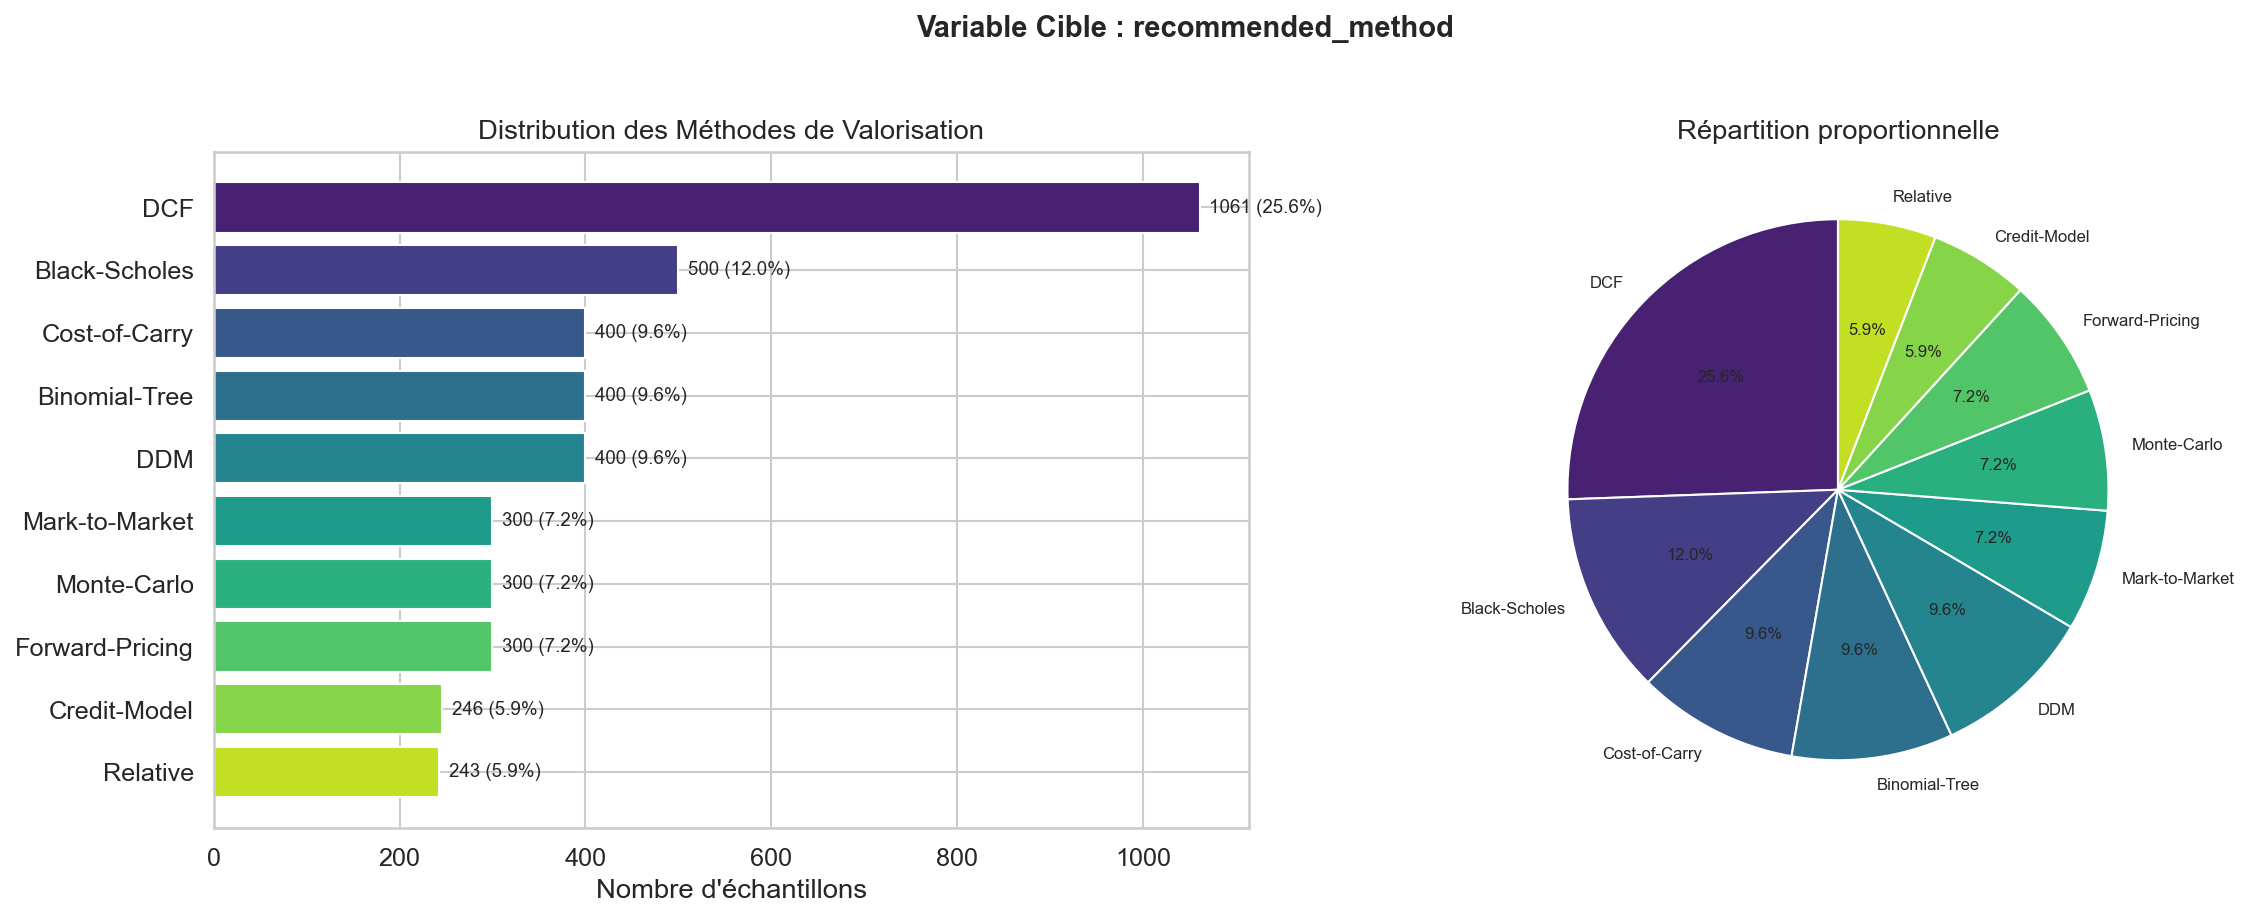


📊 Métriques de déséquilibre :
   Classe majoritaire : DCF (1061 samples)
   Classe minoritaire : Relative (243 samples)
   Ratio d'imbalance  : 4.4:1
   → ⚠️ Déséquilibre modéré — utiliser class_weight=balanced


In [12]:
# ── Distribution de la variable cible ─────────────────────────────────
target_counts = df["recommended_method"].value_counts()
order = target_counts.index

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Barplot
colors = sns.color_palette("viridis", n_colors=len(order))
bars = axes[0].barh(range(len(order)), target_counts.values, color=colors)
axes[0].set_yticks(range(len(order)))
axes[0].set_yticklabels(order)
axes[0].set_xlabel("Nombre d'échantillons")
axes[0].set_title("Distribution des Méthodes de Valorisation")
axes[0].invert_yaxis()

for i, (count, pct) in enumerate(zip(target_counts.values, target_counts.values / len(df) * 100)):
    axes[0].text(count + 10, i, f"{count} ({pct:.1f}%)", va="center", fontsize=9)

# Pie chart
axes[1].pie(target_counts.values, labels=order, autopct="%1.1f%%",
            colors=colors, startangle=90, textprops={"fontsize": 8})
axes[1].set_title("Répartition proportionnelle")

plt.suptitle("Variable Cible : recommended_method", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("reports/figures/target_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

# Métriques de déséquilibre
max_class = target_counts.max()
min_class = target_counts.min()
ratio = max_class / min_class
print(f"\n📊 Métriques de déséquilibre :")
print(f"   Classe majoritaire : {target_counts.idxmax()} ({max_class} samples)")
print(f"   Classe minoritaire : {target_counts.idxmin()} ({min_class} samples)")
print(f"   Ratio d'imbalance  : {ratio:.1f}:1")
print(f"   → {'⚠️ Déséquilibre modéré — utiliser class_weight=balanced' if ratio > 3 else '✅ Déséquilibre acceptable'}")

---
## 4. Validation Financière : Classe d'Actif × Méthode de Valorisation

C'est la **vérification la plus importante** du notebook. La matrice croisée `asset_class × recommended_method` doit montrer des **blocs diagonaux cohérents** :

| Classe d'actif | Méthodes attendues |
|---|---|
| **Bond** | DCF, Credit-Model |
| **Equity** | DDM, DCF, Relative, Mark-to-Market |
| **Option** | Black-Scholes, Binomial-Tree, Monte-Carlo |
| **Commodity** | Cost-of-Carry |
| **Currency** | Forward-Pricing |
| **Derivative** | DCF (swaps) |

Toute entrée **hors-diagonal** (ex: Bond → Black-Scholes) serait un **bug** dans la génération des données.

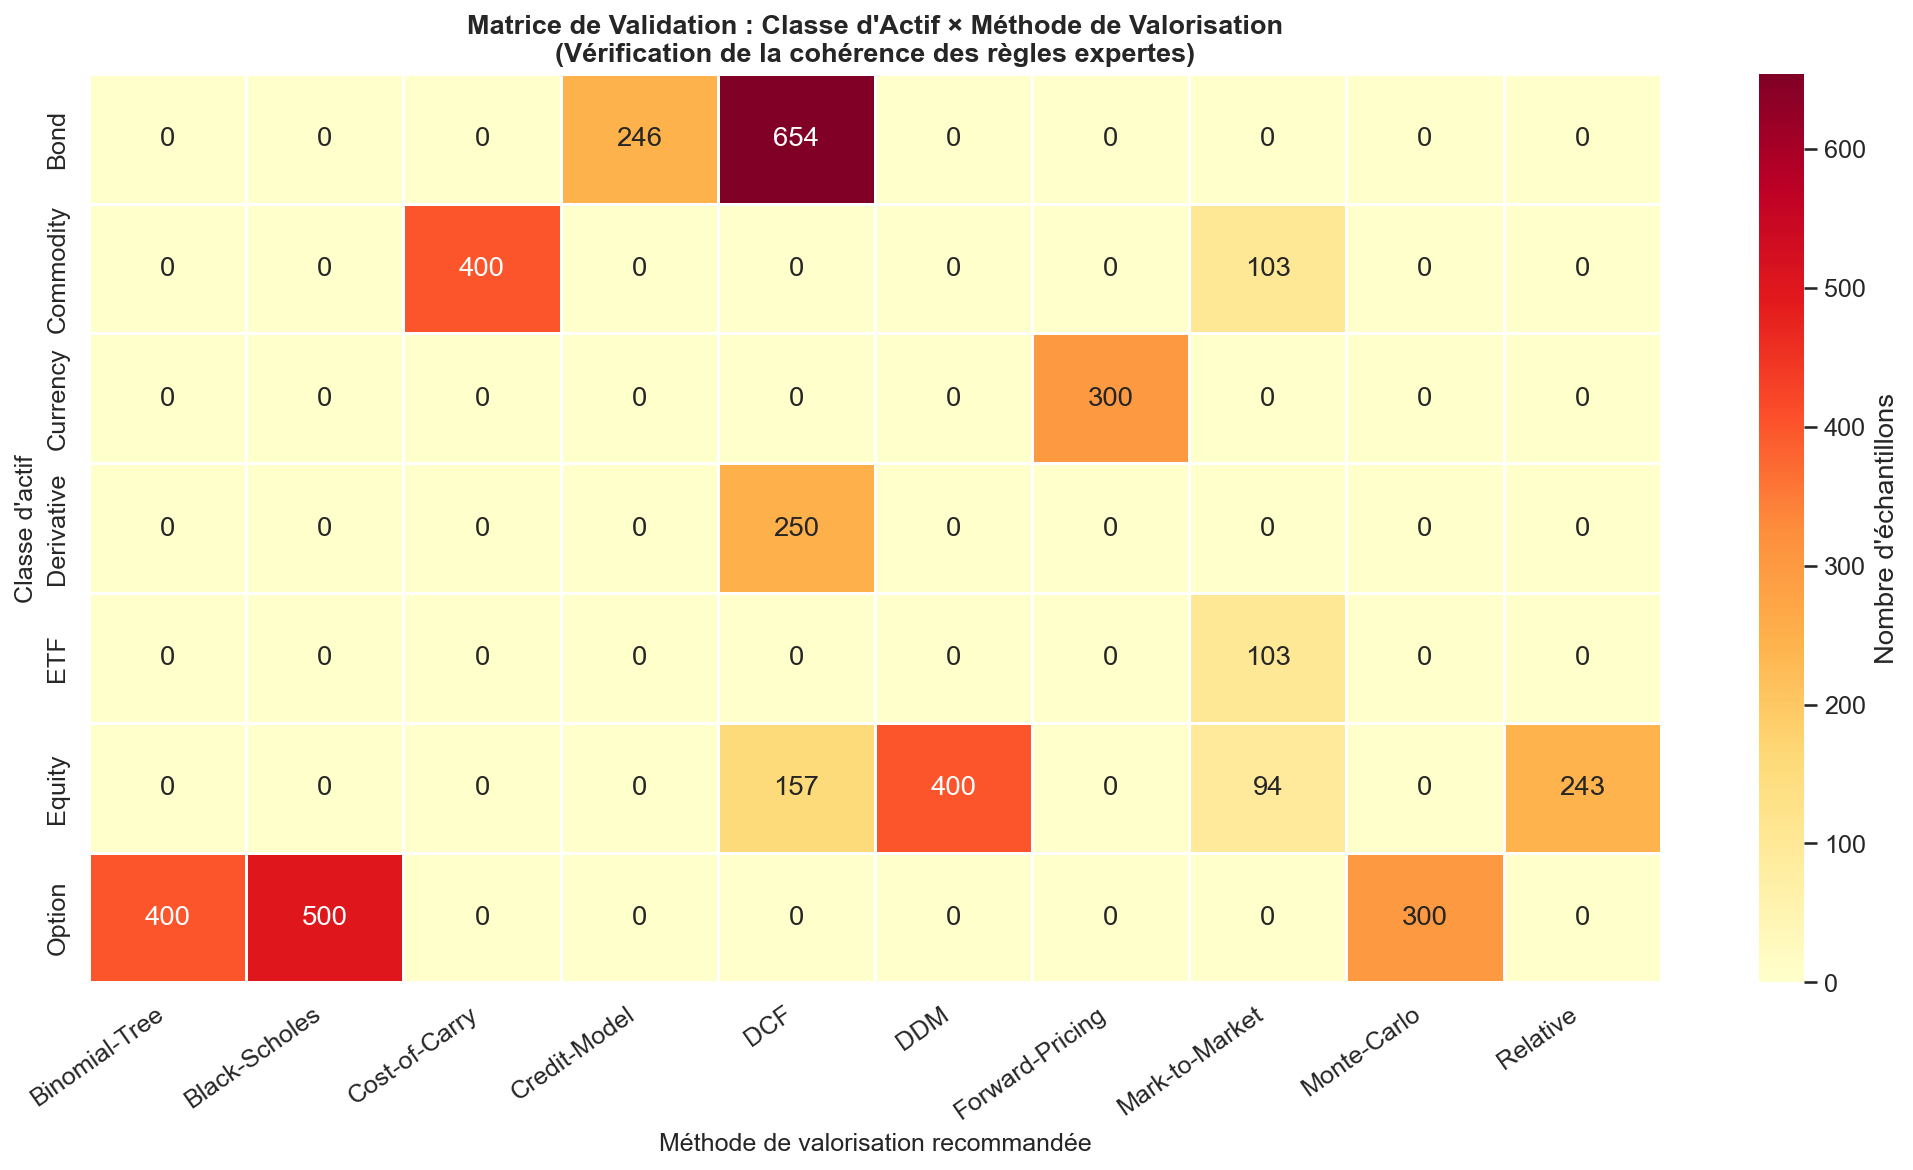

In [13]:
# ── Heatmap : asset_class × recommended_method ────────────────────────
ct = pd.crosstab(df["asset_class"], df["recommended_method"])

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(ct, annot=True, fmt="d", cmap="YlOrRd", linewidths=0.5,
            linecolor="white", ax=ax, cbar_kws={"label": "Nombre d'échantillons"})
ax.set_xlabel("Méthode de valorisation recommandée", fontsize=12)
ax.set_ylabel("Classe d'actif", fontsize=12)
ax.set_title("Matrice de Validation : Classe d'Actif × Méthode de Valorisation\n(Vérification de la cohérence des règles expertes)",
             fontsize=13, fontweight="bold")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig("reports/figures/asset_method_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

In [14]:
# ── Validation automatique des mappings attendus ─────────────────────
expected_mappings = {
    "Bond":       {"DCF", "Credit-Model"},
    "Equity":     {"DDM", "DCF", "Relative", "Mark-to-Market"},
    "Option":     {"Black-Scholes", "Binomial-Tree", "Monte-Carlo"},
    "Commodity":  {"Cost-of-Carry", "Mark-to-Market"},
    "Currency":   {"Forward-Pricing"},
    "Derivative": {"DCF"},
}

print("🔍 Validation des mappings asset_class → recommended_method :")
print("─" * 70)
violations = []

for asset_class in df["asset_class"].unique():
    actual = set(df[df["asset_class"] == asset_class]["recommended_method"].unique())
    expected = expected_mappings.get(asset_class, set())
    
    unexpected = actual - expected
    missing = expected - actual
    
    status = "✅" if not unexpected else "⚠️"
    print(f"\n{status} {asset_class}")
    print(f"   Attendu   : {sorted(expected)}")
    print(f"   Observé   : {sorted(actual)}")
    
    if unexpected:
        print(f"   ❌ ANOMALIE : {sorted(unexpected)} ne devrait pas apparaître pour {asset_class}")
        violations.extend([(asset_class, m) for m in unexpected])
    if missing:
        print(f"   ℹ️  Absent  : {sorted(missing)} (peut être normal si peu d'exemples)")

if not violations:
    print(f"\n✅ Aucune violation détectée — les règles expertes sont financièrement cohérentes.")
else:
    print(f"\n⚠️ {len(violations)} violation(s) détectée(s) — corriger le pipeline de génération.")

🔍 Validation des mappings asset_class → recommended_method :
──────────────────────────────────────────────────────────────────────

✅ Bond
   Attendu   : ['Credit-Model', 'DCF']
   Observé   : ['Credit-Model', 'DCF']

✅ Commodity
   Attendu   : ['Cost-of-Carry', 'Mark-to-Market']
   Observé   : ['Cost-of-Carry', 'Mark-to-Market']

✅ Equity
   Attendu   : ['DCF', 'DDM', 'Mark-to-Market', 'Relative']
   Observé   : ['DCF', 'DDM', 'Mark-to-Market', 'Relative']

✅ Option
   Attendu   : ['Binomial-Tree', 'Black-Scholes', 'Monte-Carlo']
   Observé   : ['Binomial-Tree', 'Black-Scholes', 'Monte-Carlo']

✅ Currency
   Attendu   : ['Forward-Pricing']
   Observé   : ['Forward-Pricing']

✅ Derivative
   Attendu   : ['DCF']
   Observé   : ['DCF']

⚠️ ETF
   Attendu   : []
   Observé   : ['Mark-to-Market']
   ❌ ANOMALIE : ['Mark-to-Market'] ne devrait pas apparaître pour ETF

⚠️ 1 violation(s) détectée(s) — corriger le pipeline de génération.


### 4.1 Analyse Fine : Sous-Classe × Méthode

L'`asset_subclass` apporte une granularité supplémentaire (ex: Government Bond vs Corporate Bond, European Option vs American Option).

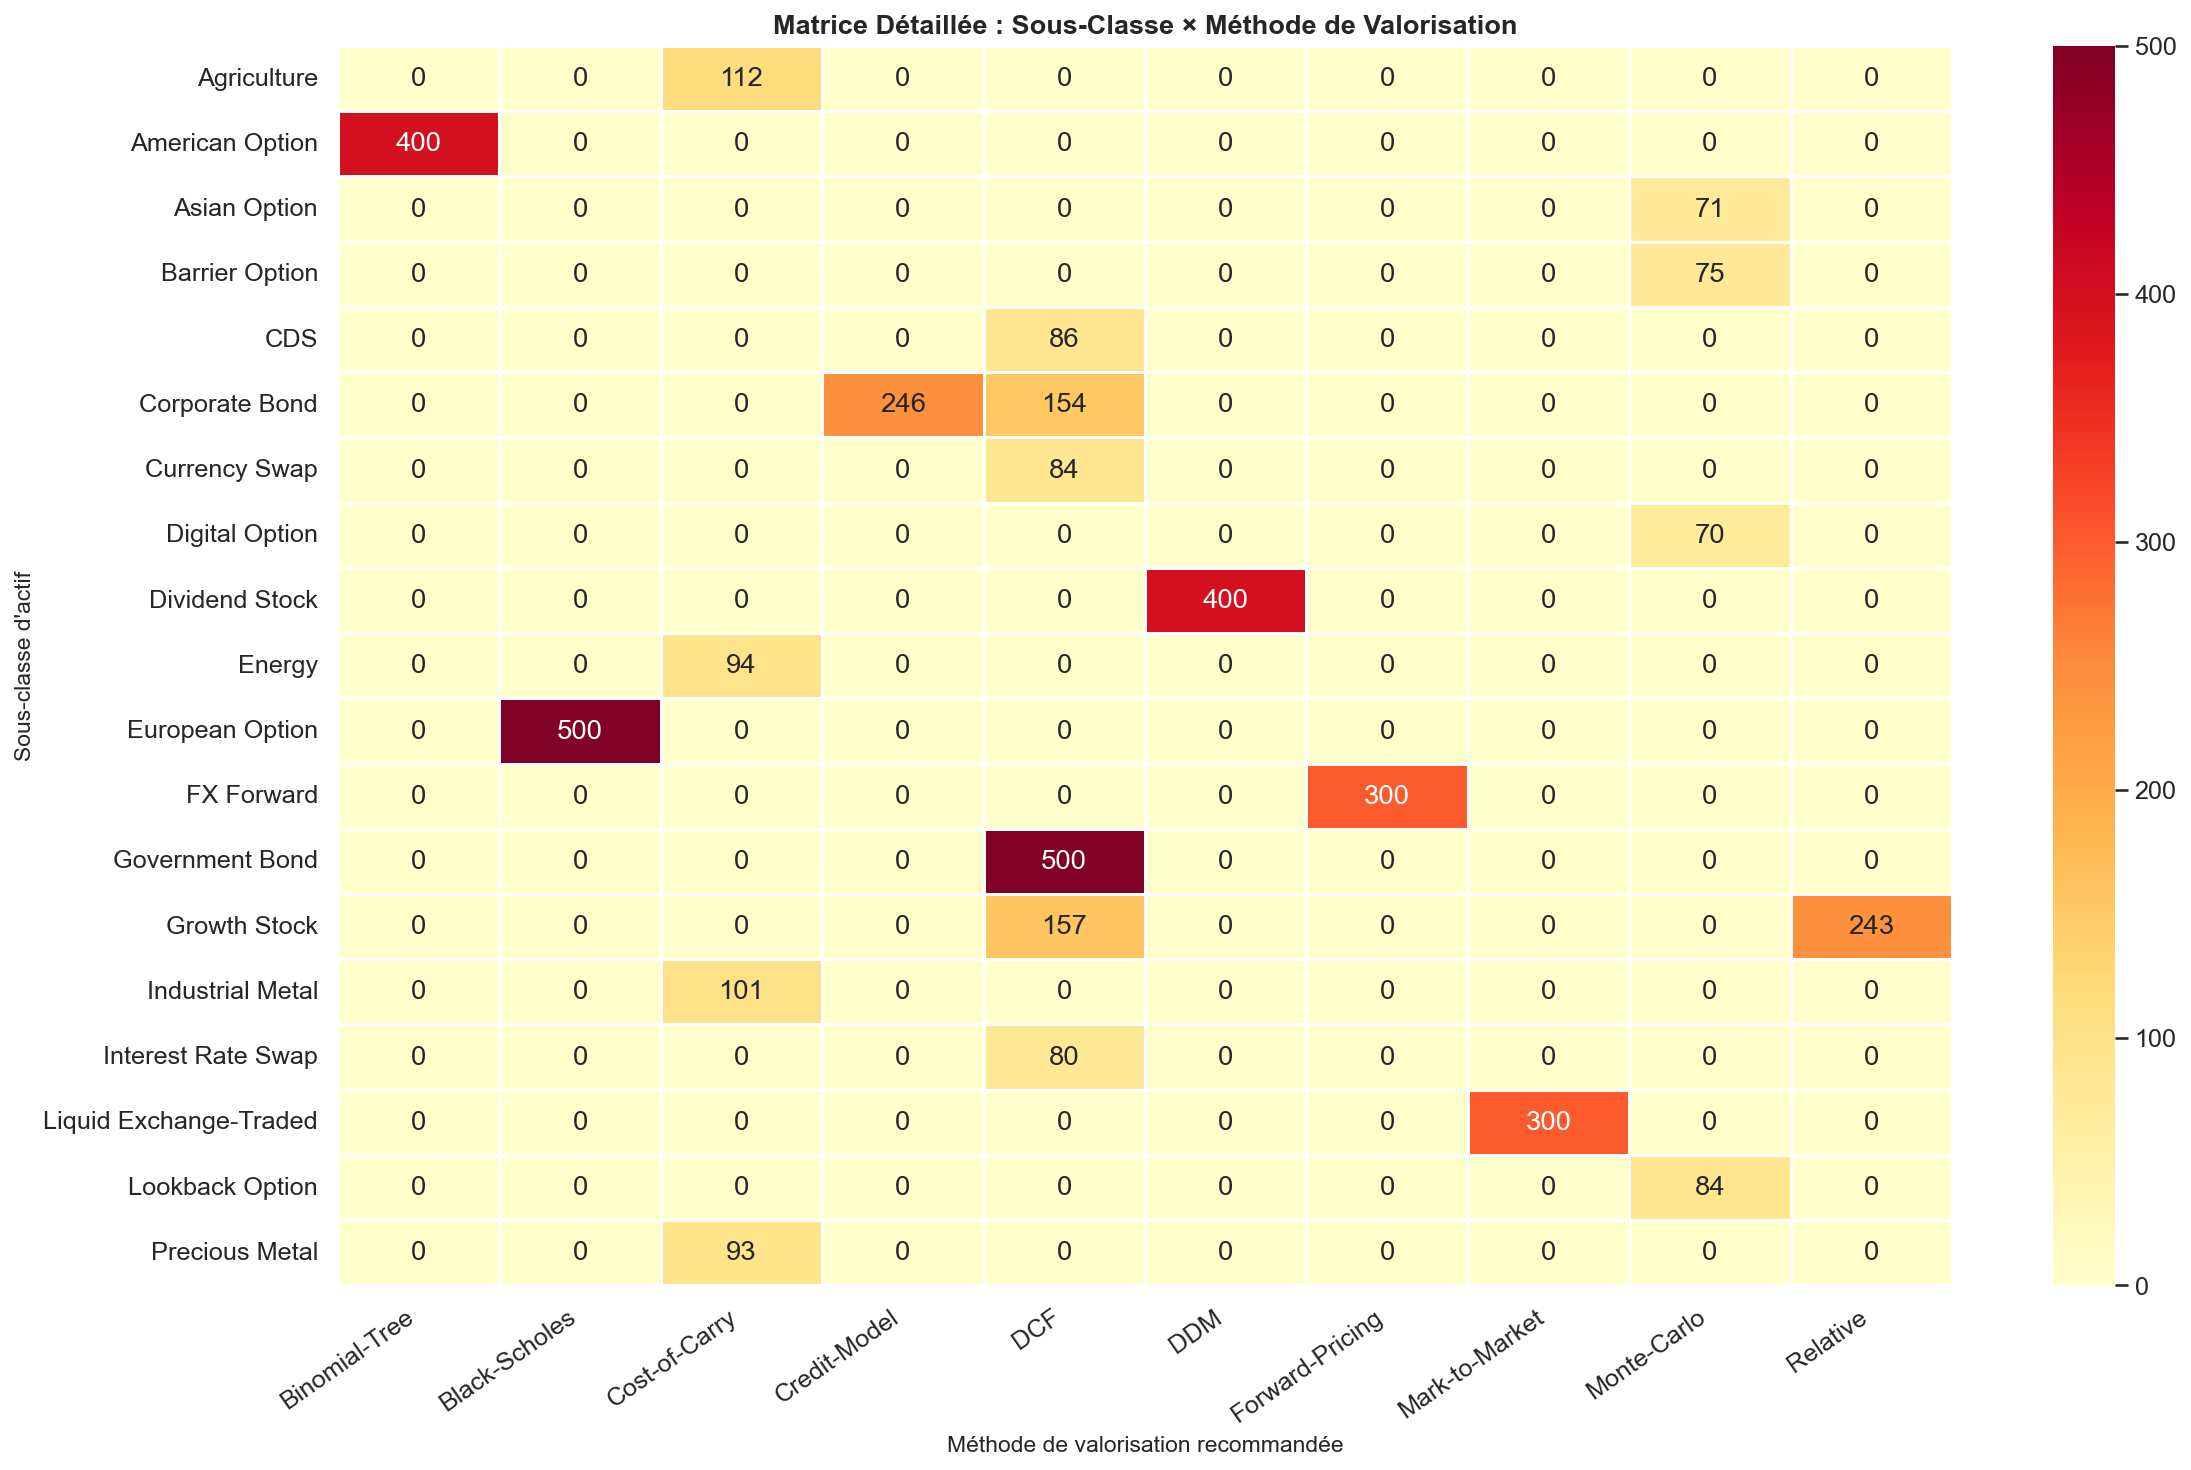


📋 Nombre de sous-classes : 19

Répartition des sous-classes :
asset_subclass
Government Bond           500
European Option           500
Corporate Bond            400
American Option           400
Dividend Stock            400
Growth Stock              400
FX Forward                300
Liquid Exchange-Traded    300
Agriculture               112
Industrial Metal          101
Energy                     94
Precious Metal             93
CDS                        86
Lookback Option            84
Currency Swap              84
Interest Rate Swap         80
Barrier Option             75
Asian Option               71
Digital Option             70


In [15]:
# ── Heatmap : asset_subclass × recommended_method ─────────────────────
ct_sub = pd.crosstab(df["asset_subclass"], df["recommended_method"])

fig, ax = plt.subplots(figsize=(16, 10))
sns.heatmap(ct_sub, annot=True, fmt="d", cmap="YlOrRd", linewidths=0.5,
            linecolor="white", ax=ax)
ax.set_xlabel("Méthode de valorisation recommandée", fontsize=11)
ax.set_ylabel("Sous-classe d'actif", fontsize=11)
ax.set_title("Matrice Détaillée : Sous-Classe × Méthode de Valorisation", fontsize=13, fontweight="bold")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig("reports/figures/subclass_method_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\n📋 Nombre de sous-classes : {df['asset_subclass'].nunique()}")
print(f"\nRépartition des sous-classes :")
print(df["asset_subclass"].value_counts().to_string())

---
## 5. Analyse des Features Binaires par Méthode de Valorisation

Cette heatmap montre la **moyenne de chaque feature binaire** pour chaque méthode cible. Elle permet de vérifier que les features discriminent correctement les classes.

**Patterns attendus :**
- `has_early_exercise` ≈ 1.0 pour Binomial-Tree, ≈ 0.0 pour Black-Scholes
- `is_path_dependent` ≈ 1.0 pour Monte-Carlo uniquement
- `has_cash_flows` ≈ 1.0 pour DCF et DDM
- `has_options_features` ≈ 1.0 pour BSM, Binomial-Tree, Monte-Carlo
- `has_credit_risk` élevé pour Credit-Model

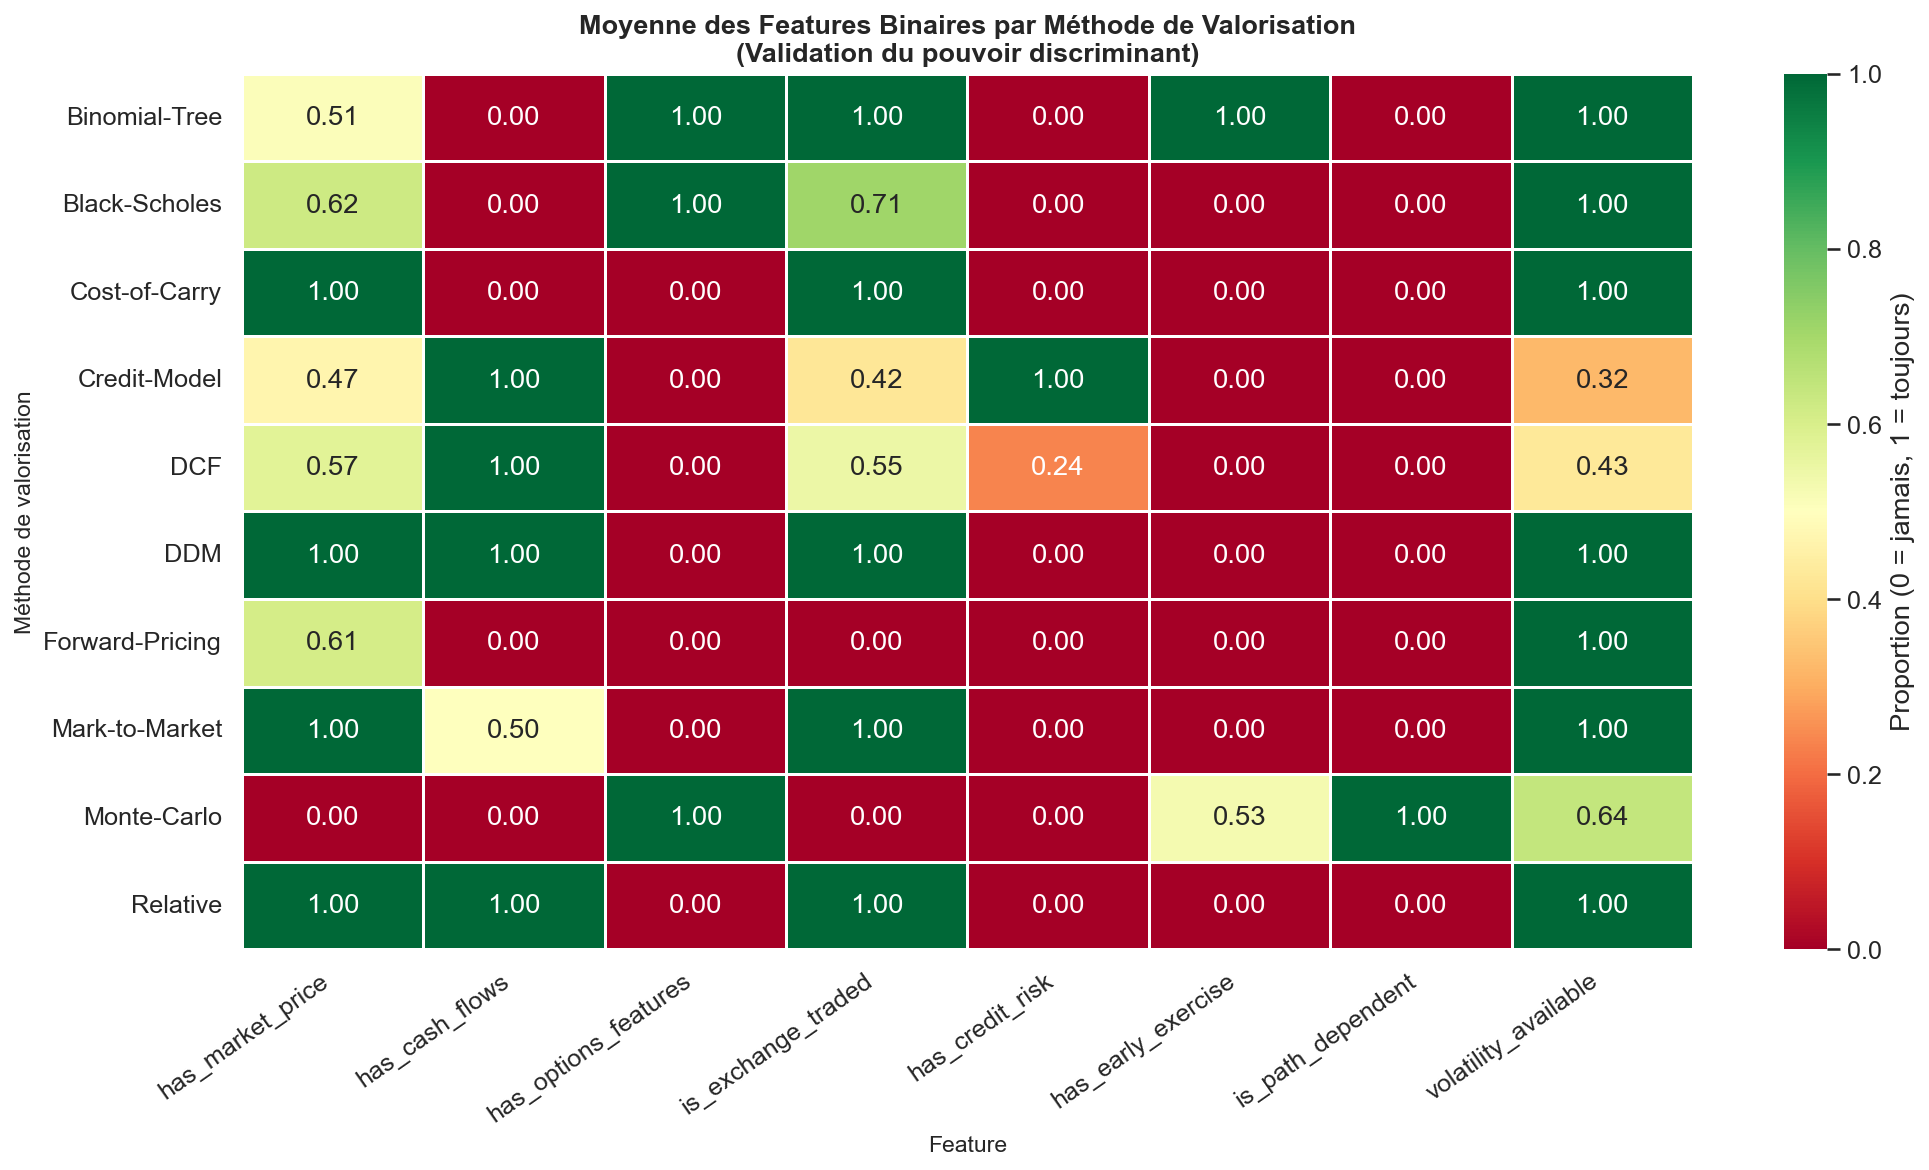

In [16]:
# ── Heatmap des features binaires par méthode ─────────────────────────
bool_cols = [
    "has_market_price", "has_cash_flows", "has_options_features",
    "is_exchange_traded", "has_credit_risk", "has_early_exercise",
    "is_path_dependent", "volatility_available"
]

# Vérifier que toutes les colonnes existent
bool_cols_present = [c for c in bool_cols if c in df.columns]

means = df.groupby("recommended_method")[bool_cols_present].mean()

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(means, annot=True, fmt=".2f", cmap="RdYlGn", linewidths=0.5,
            vmin=0, vmax=1, ax=ax, cbar_kws={"label": "Proportion (0 = jamais, 1 = toujours)"})
ax.set_title("Moyenne des Features Binaires par Méthode de Valorisation\n(Validation du pouvoir discriminant)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Feature", fontsize=11)
ax.set_ylabel("Méthode de valorisation", fontsize=11)
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig("reports/figures/feature_heatmap_bool.png", dpi=150, bbox_inches="tight")
plt.show()

In [17]:
# ── Validation automatique des patterns attendus ─────────────────────
expected_patterns = [
    ("has_early_exercise",    "Binomial-Tree",  ">=", 0.8,  "American options → early exercise"),
    ("has_early_exercise",    "Black-Scholes",  "<=", 0.1,  "European options → pas d'early exercise"),
    ("is_path_dependent",     "Monte-Carlo",    ">=", 0.8,  "Exotiques → dépendance au chemin"),
    ("is_path_dependent",     "Black-Scholes",  "<=", 0.1,  "BSM → pas de path dependency"),
    ("has_cash_flows",        "DCF",            ">=", 0.8,  "DCF nécessite des flux identifiables"),
    ("has_cash_flows",        "DDM",            ">=", 0.8,  "DDM = dividendes = cash flows"),
    ("has_options_features",  "Black-Scholes",  ">=", 0.9,  "BSM = modèle d'options"),
    ("has_options_features",  "Binomial-Tree",  ">=", 0.9,  "Binomial = modèle d'options"),
    ("has_options_features",  "Monte-Carlo",    ">=", 0.9,  "MC pour options exotiques"),
    ("has_options_features",  "DCF",            "<=", 0.1,  "DCF ≠ options"),
    ("has_credit_risk",       "Credit-Model",   ">=", 0.8,  "Credit-Model → risque de crédit"),
    ("has_market_price",      "Mark-to-Market", ">=", 0.8,  "MtM nécessite un prix observable"),
]

print("🔍 Validation des patterns features ↔ méthodes :")
print("─" * 80)

n_pass = 0
n_fail = 0
for feat, method, op, threshold, reason in expected_patterns:
    if feat not in df.columns or method not in means.index:
        print(f"⏭️  {feat} / {method} — données insuffisantes")
        continue
    
    val = means.loc[method, feat]
    if op == ">=":
        passed = val >= threshold
    else:
        passed = val <= threshold
    
    status = "✅" if passed else "❌"
    if passed:
        n_pass += 1
    else:
        n_fail += 1
    print(f"{status} {feat:<25} × {method:<15} = {val:.2f} ({op} {threshold})  — {reason}")

print(f"\n📊 Résultat : {n_pass} validés, {n_fail} échoués sur {n_pass + n_fail} tests")

🔍 Validation des patterns features ↔ méthodes :
────────────────────────────────────────────────────────────────────────────────
✅ has_early_exercise        × Binomial-Tree   = 1.00 (>= 0.8)  — American options → early exercise
✅ has_early_exercise        × Black-Scholes   = 0.00 (<= 0.1)  — European options → pas d'early exercise
✅ is_path_dependent         × Monte-Carlo     = 1.00 (>= 0.8)  — Exotiques → dépendance au chemin
✅ is_path_dependent         × Black-Scholes   = 0.00 (<= 0.1)  — BSM → pas de path dependency
✅ has_cash_flows            × DCF             = 1.00 (>= 0.8)  — DCF nécessite des flux identifiables
✅ has_cash_flows            × DDM             = 1.00 (>= 0.8)  — DDM = dividendes = cash flows
✅ has_options_features      × Black-Scholes   = 1.00 (>= 0.9)  — BSM = modèle d'options
✅ has_options_features      × Binomial-Tree   = 1.00 (>= 0.9)  — Binomial = modèle d'options
✅ has_options_features      × Monte-Carlo     = 1.00 (>= 0.9)  — MC pour options exotiques
✅ has_

---
## 6. Distribution de la Maturité par Méthode

La maturité (`maturity_years`) est une feature continue critique : elle distingue les instruments court terme (options, forwards) des instruments long terme (obligations). Les valeurs NaN correspondent aux actifs **perpétuels** (actions, ETFs).

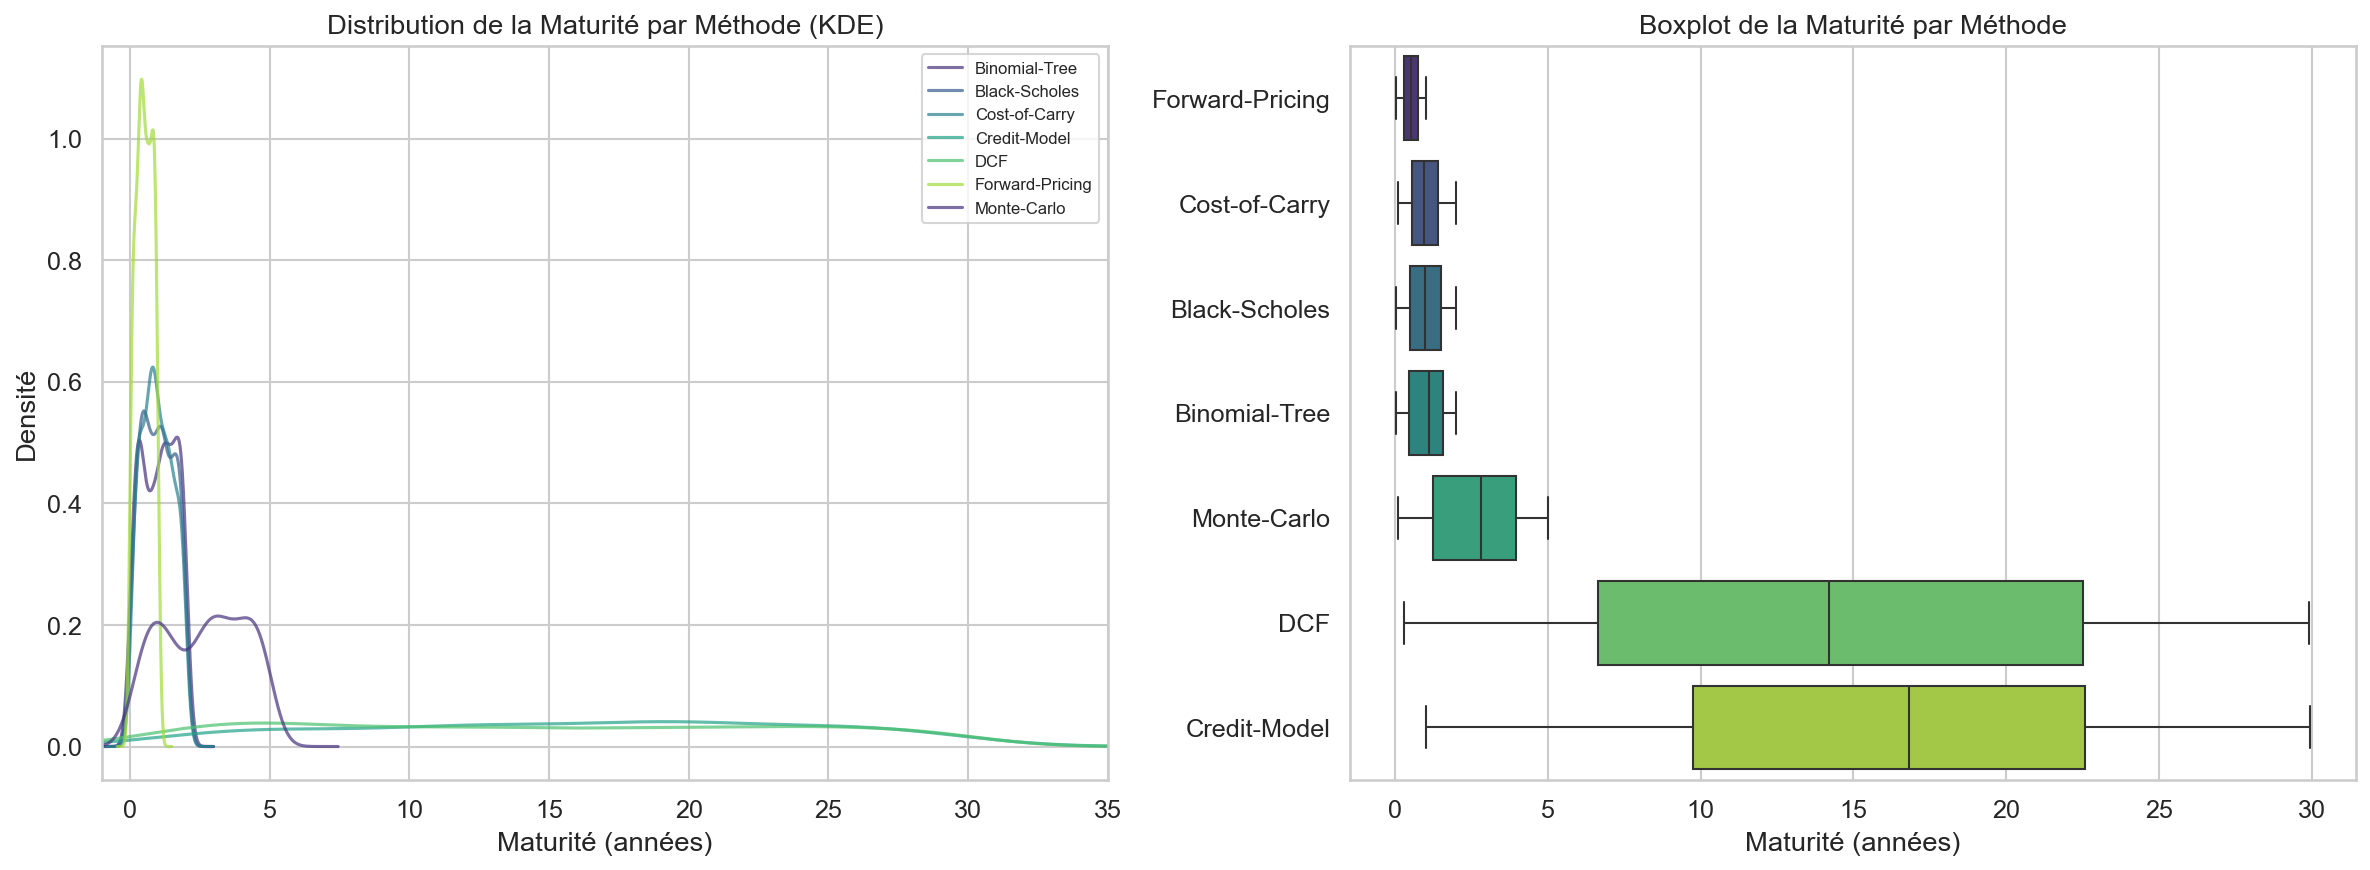


📊 Valeurs NaN de maturity_years par méthode (= actifs perpétuels) :
   DCF                  :  157 NaN / 1061 total ( 14.8%)
   Black-Scholes        :    0 NaN /  500 total (  0.0%)
   Cost-of-Carry        :    0 NaN /  400 total (  0.0%)
   Binomial-Tree        :    0 NaN /  400 total (  0.0%)
   DDM                  :  400 NaN /  400 total (100.0%)
   Mark-to-Market       :  300 NaN /  300 total (100.0%)
   Monte-Carlo          :    0 NaN /  300 total (  0.0%)
   Forward-Pricing      :    0 NaN /  300 total (  0.0%)
   Credit-Model         :    0 NaN /  246 total (  0.0%)
   Relative             :  243 NaN /  243 total (100.0%)


In [18]:
# ── KDE plot : maturity par méthode ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# KDE pour les méthodes avec maturité définie
ax = axes[0]
methods_with_maturity = df.dropna(subset=["maturity_years"]).groupby("recommended_method")
for method, group in methods_with_maturity:
    if len(group) > 10:
        group["maturity_years"].plot(kind="kde", ax=ax, label=method, alpha=0.7)

ax.set_xlabel("Maturité (années)")
ax.set_ylabel("Densité")
ax.set_title("Distribution de la Maturité par Méthode (KDE)")
ax.legend(fontsize=8, loc="upper right")
ax.set_xlim(-1, 35)

# Boxplot
ax2 = axes[1]
maturity_data = df.dropna(subset=["maturity_years"])
order_mat = maturity_data.groupby("recommended_method")["maturity_years"].median().sort_values().index
sns.boxplot(data=maturity_data, y="recommended_method", x="maturity_years",
            order=order_mat, ax=ax2, palette="viridis")
ax2.set_xlabel("Maturité (années)")
ax2.set_ylabel("")
ax2.set_title("Boxplot de la Maturité par Méthode")

plt.tight_layout()
plt.savefig("reports/figures/maturity_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

# Résumé NaN par méthode
print("\n📊 Valeurs NaN de maturity_years par méthode (= actifs perpétuels) :")
nan_by_method = df.groupby("recommended_method")["maturity_years"].apply(lambda x: x.isnull().sum())
total_by_method = df["recommended_method"].value_counts()
for method in total_by_method.index:
    n_nan = nan_by_method.get(method, 0)
    n_total = total_by_method[method]
    print(f"   {method:<20} : {n_nan:>4} NaN / {n_total:>4} total ({n_nan/n_total*100:>5.1f}%)")

---
## 7. Analyse de la Hiérarchie IFRS 13

La norme IFRS 13 définit 3 niveaux de données pour la juste valeur :
- **Level 1** : Prix cotés sur des marchés actifs (→ Mark-to-Market obligatoire)
- **Level 2** : Données observables indirectes (→ modèles avec inputs de marché)
- **Level 3** : Données non observables (→ modèles purs, Monte-Carlo, Credit-Model)

Cette hiérarchie constitue une **contrainte réglementaire** qui s'impose au modèle ML.

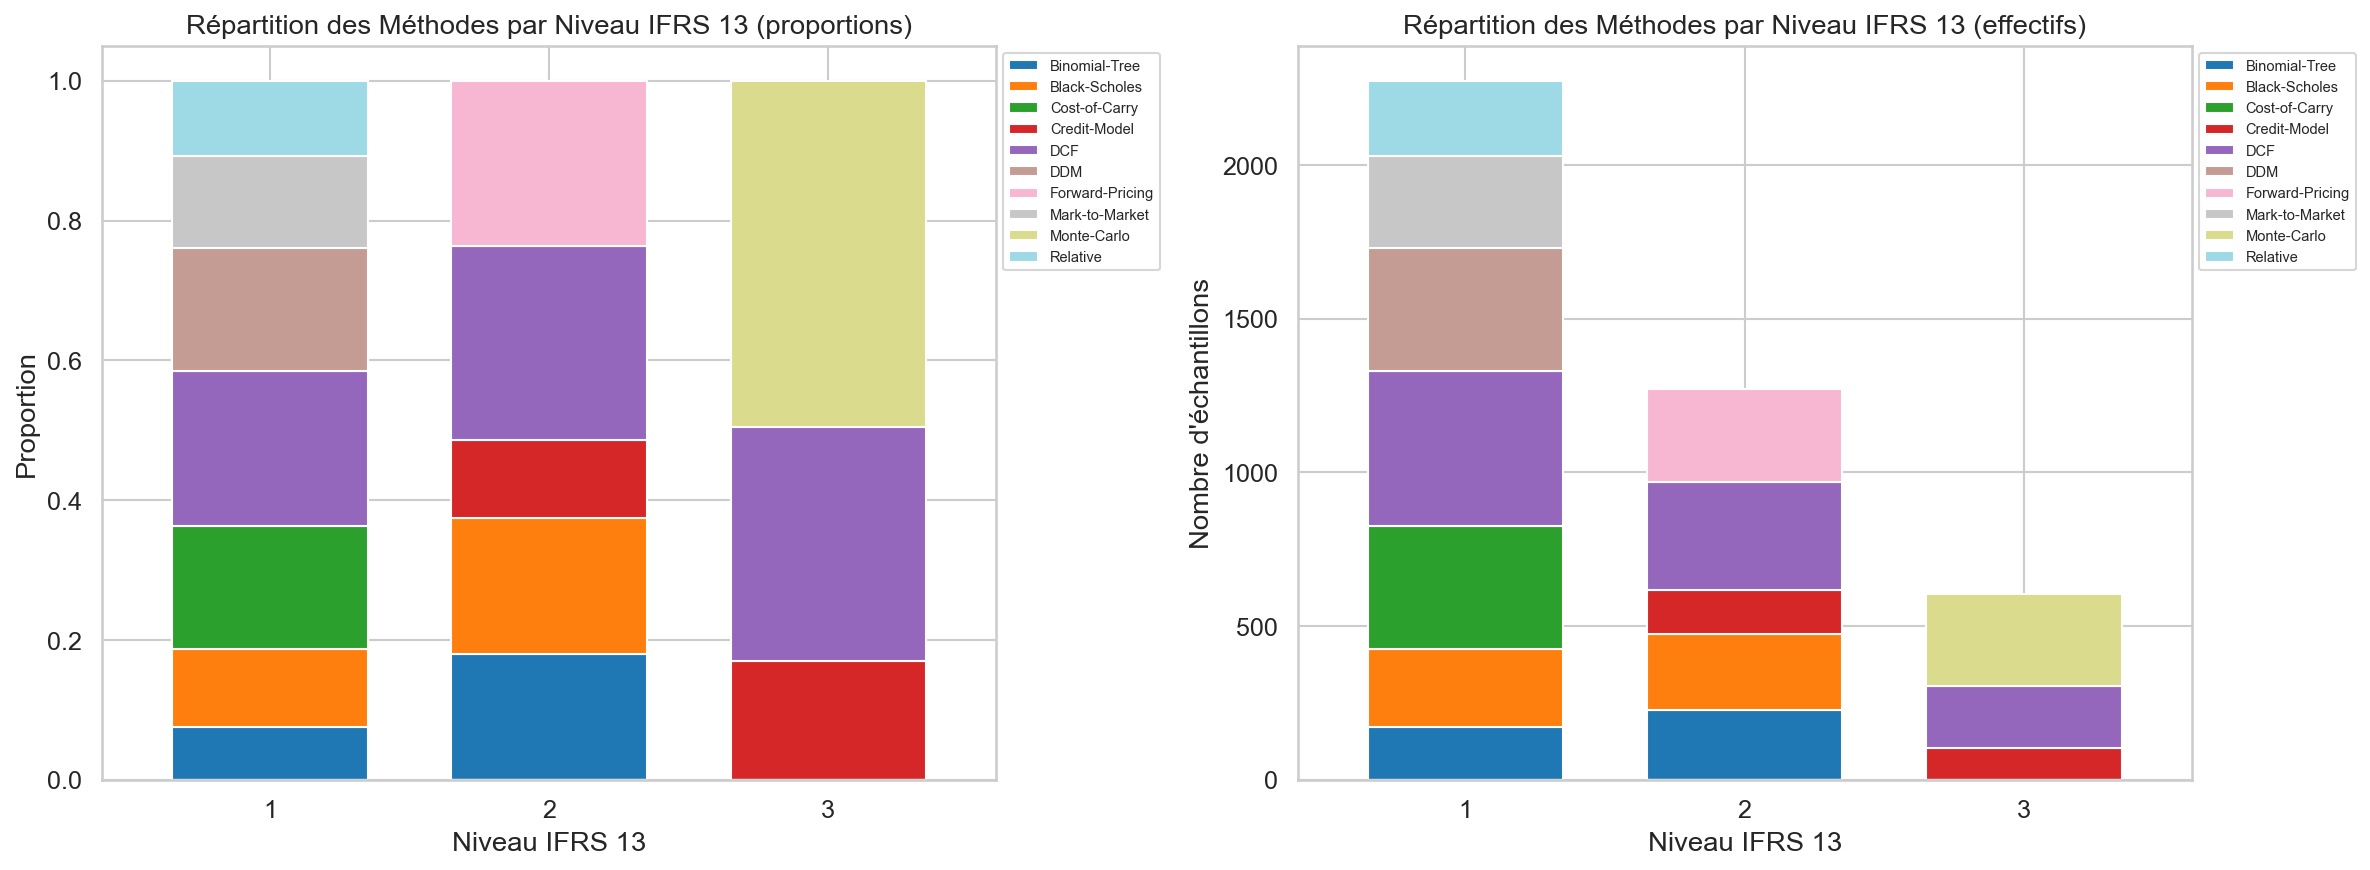

In [19]:
# ── Stacked bar : distribution des méthodes par IFRS level ────────────
ct_ifrs = pd.crosstab(df["ifrs_level"], df["recommended_method"], normalize="index")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Stacked bar (proportions)
ct_ifrs.plot(kind="bar", stacked=True, ax=axes[0], colormap="tab20", width=0.7)
axes[0].set_xlabel("Niveau IFRS 13")
axes[0].set_ylabel("Proportion")
axes[0].set_title("Répartition des Méthodes par Niveau IFRS 13 (proportions)")
axes[0].legend(fontsize=7, bbox_to_anchor=(1.0, 1), loc="upper left")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

# Absolute counts
ct_ifrs_abs = pd.crosstab(df["ifrs_level"], df["recommended_method"])
ct_ifrs_abs.plot(kind="bar", stacked=True, ax=axes[1], colormap="tab20", width=0.7)
axes[1].set_xlabel("Niveau IFRS 13")
axes[1].set_ylabel("Nombre d'échantillons")
axes[1].set_title("Répartition des Méthodes par Niveau IFRS 13 (effectifs)")
axes[1].legend(fontsize=7, bbox_to_anchor=(1.0, 1), loc="upper left")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.savefig("reports/figures/ifrs_level_methods.png", dpi=150, bbox_inches="tight")
plt.show()

In [20]:
# ── Validation des contraintes IFRS ───────────────────────────────────
print("🔍 Validation des contraintes IFRS 13 :")
print("─" * 60)

# Level 1 + has_market_price + liquidity=High → doit favoriser Mark-to-Market
l1_liquid = df[(df["ifrs_level"] == 1) & (df["has_market_price"] == 1) & (df["liquidity"] == "High")]
if len(l1_liquid) > 0:
    mtm_pct = (l1_liquid["recommended_method"] == "Mark-to-Market").mean() * 100
    print(f"\n✅ Level 1 + prix observable + liquidité élevée ({len(l1_liquid)} samples)")
    print(f"   → Mark-to-Market : {mtm_pct:.1f}% (attendu : ~100% après post-processing IFRS)")
else:
    print("\nℹ️  Aucun échantillon Level 1 + market price + High liquidity")

# Level 3 → ne doit JAMAIS contenir Mark-to-Market
l3 = df[df["ifrs_level"] == 3]
if len(l3) > 0:
    mtm_in_l3 = (l3["recommended_method"] == "Mark-to-Market").sum()
    print(f"\n{'✅' if mtm_in_l3 == 0 else '❌'} Level 3 ({len(l3)} samples)")
    print(f"   → Mark-to-Market présent : {mtm_in_l3} fois (attendu : 0)")
else:
    print("\nℹ️  Aucun échantillon Level 3")

# Répartition globale par level
print(f"\n📊 Répartition par niveau IFRS :")
for level in sorted(df["ifrs_level"].unique()):
    n = (df["ifrs_level"] == level).sum()
    print(f"   Level {level} : {n:>5} échantillons ({n/len(df)*100:.1f}%)")

🔍 Validation des contraintes IFRS 13 :
────────────────────────────────────────────────────────────

✅ Level 1 + prix observable + liquidité élevée (1310 samples)
   → Mark-to-Market : 22.9% (attendu : ~100% après post-processing IFRS)

✅ Level 3 (606 samples)
   → Mark-to-Market présent : 0 fois (attendu : 0)

📊 Répartition par niveau IFRS :
   Level 1 :  2274 échantillons (54.8%)
   Level 2 :  1270 échantillons (30.6%)
   Level 3 :   606 échantillons (14.6%)


---
## 8. Matrice de Corrélation et Analyse de Redondance

Vérifier les corrélations entre features permet d'identifier :
- Les **features redondantes** (corrélation > 0.9) → à supprimer ou fusionner
- Les **dépendances attendues** (ex: `has_options_features` et `has_early_exercise` ne doivent PAS être parfaitement corrélées)

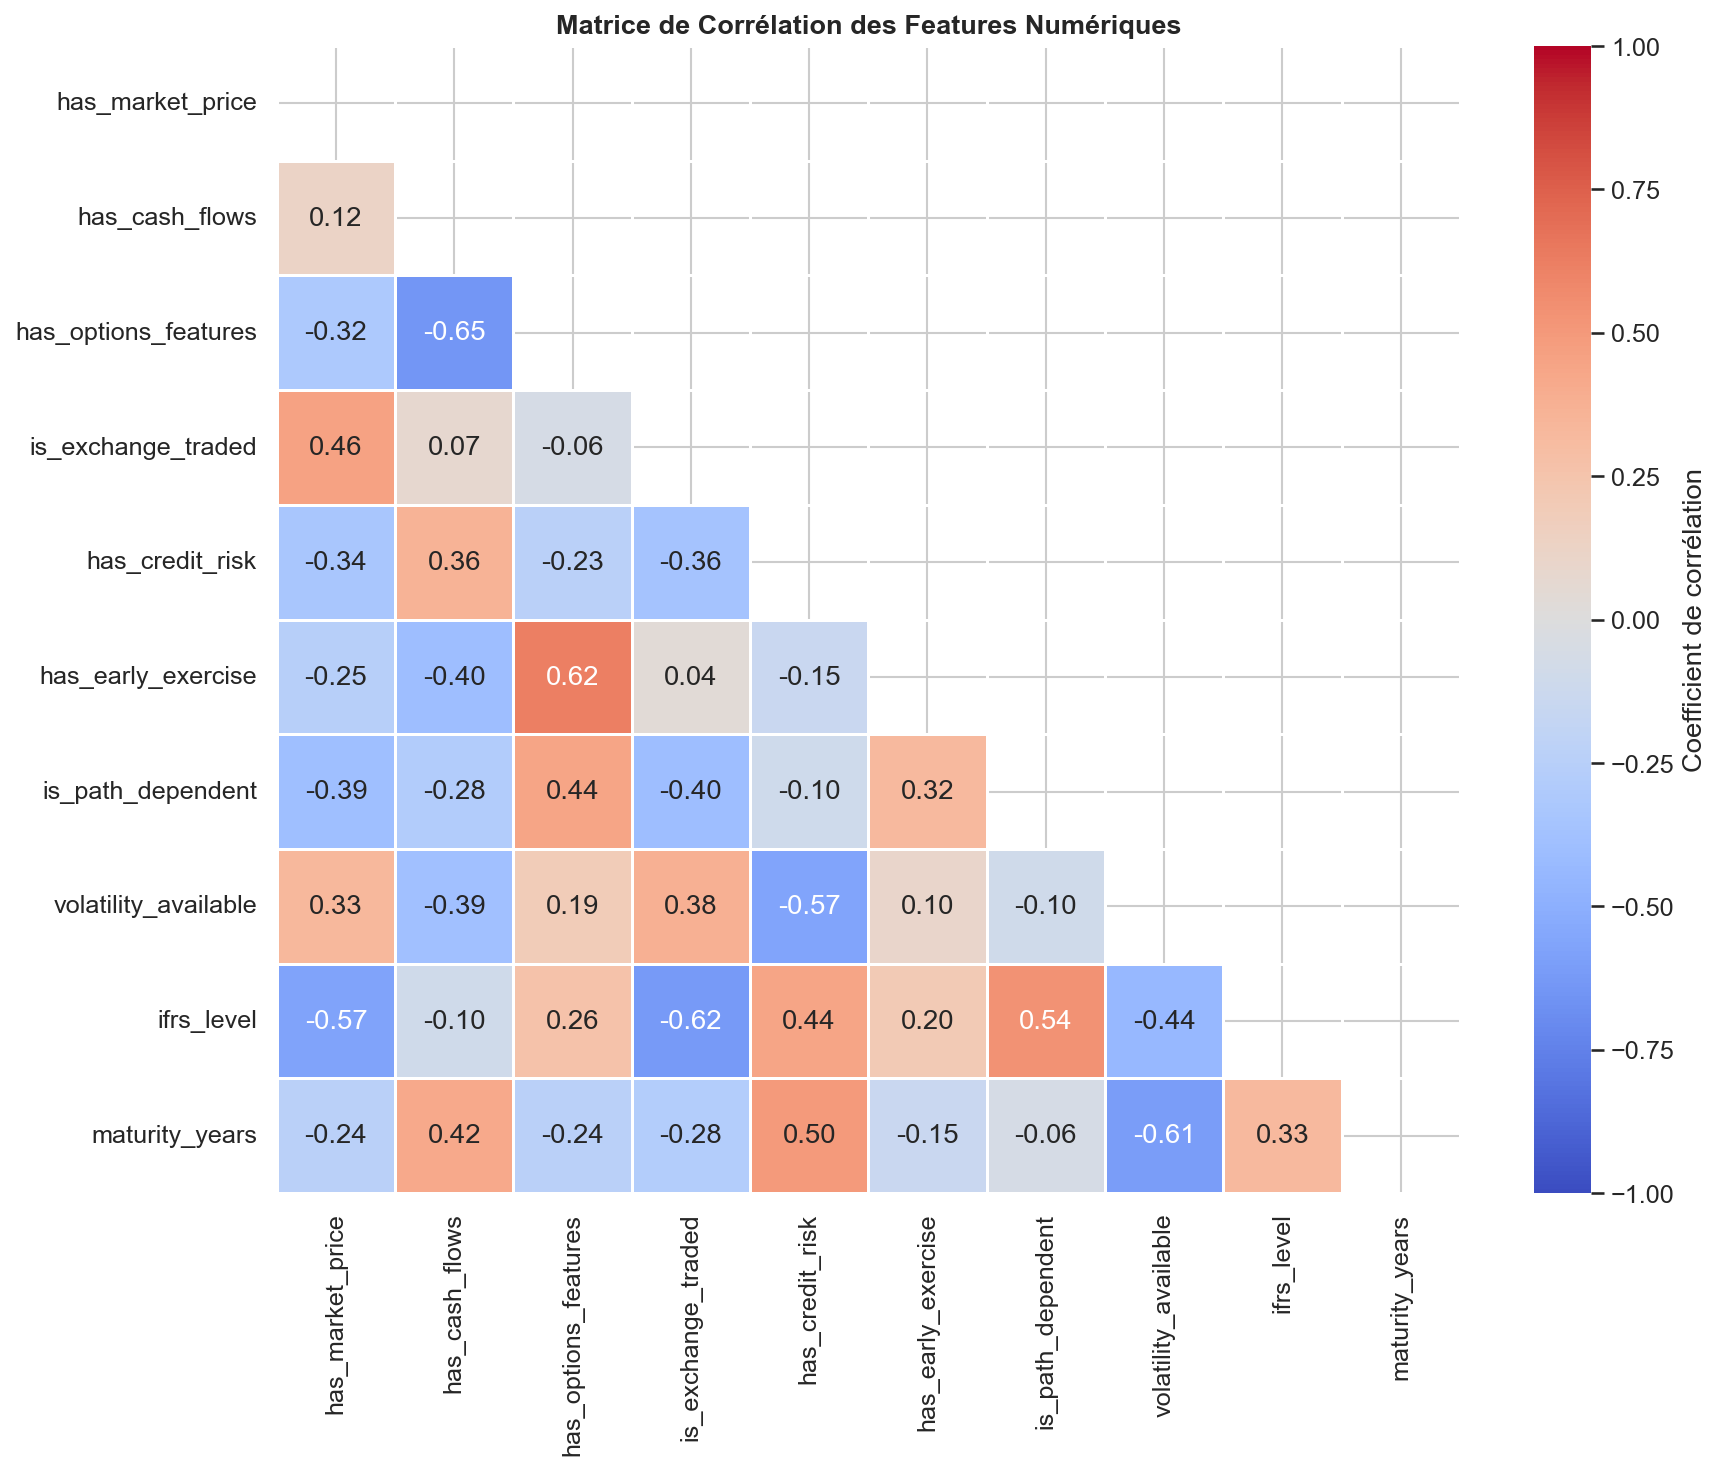


🔍 Paires fortement corrélées (|r| > 0.7) :
────────────────────────────────────────────────────────────
   ✅ Aucune paire avec |r| > 0.7 — pas de redondance détectée.

📌 has_options_features × has_early_exercise = 0.619
   ✅ Pas de corrélation parfaite (European options: options=1, early_exercise=0)


In [21]:
# ── Matrice de corrélation ─────────────────────────────────────────────
numeric_cols = [c for c in bool_cols_present + ["ifrs_level", "maturity_years"] if c in df.columns]
numeric_df = df[numeric_cols].copy()
numeric_df["maturity_years"] = numeric_df["maturity_years"].fillna(-1)  # sentinel pour corrélation

corr = numeric_df.corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax,
            cbar_kws={"label": "Coefficient de corrélation"})
ax.set_title("Matrice de Corrélation des Features Numériques", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("reports/figures/correlation_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Alertes de redondance ────────────────────────────────────────────
print("\n🔍 Paires fortement corrélées (|r| > 0.7) :")
print("─" * 60)
high_corr_found = False
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        r = corr.iloc[i, j]
        if abs(r) > 0.7:
            high_corr_found = True
            level = "⚠️ REDONDANCE" if abs(r) > 0.9 else "ℹ️  Corrélation forte"
            print(f"   {level} : {corr.columns[i]} × {corr.columns[j]} = {r:.3f}")

if not high_corr_found:
    print("   ✅ Aucune paire avec |r| > 0.7 — pas de redondance détectée.")

# Vérification spécifique
if "has_options_features" in corr.columns and "has_early_exercise" in corr.columns:
    r_oe = corr.loc["has_options_features", "has_early_exercise"]
    print(f"\n📌 has_options_features × has_early_exercise = {r_oe:.3f}")
    if abs(r_oe) < 0.9:
        print("   ✅ Pas de corrélation parfaite (European options: options=1, early_exercise=0)")
    else:
        print("   ❌ Corrélation trop forte — les options européennes ne sont pas distinguées")

---
## 9. Vérification des Données Réelles Collectées

Avant d'utiliser les données réelles pour **enrichir** le dataset synthétique (Phase 2 — Feature Engineering), vérifions leur qualité et cohérence.

### 9.1 Catalogue des Instruments (FinanceDatabase)

In [22]:
# ── Catalogue des instruments ──────────────────────────────────────────
catalog_path = f"{DATA_ROOT}/catalogs/full_instrument_catalog.csv"
if os.path.exists(catalog_path):
    catalog = pd.read_csv(catalog_path, low_memory=False)
    print(f"📐 Dimensions : {catalog.shape[0]:,} instruments × {catalog.shape[1]} colonnes")
    print(f"\n📋 Colonnes : {list(catalog.columns)}")
    print(f"\n📊 Types d'instruments (si colonne 'type' ou 'category' présente) :")
    
    # Chercher la colonne de type d'instrument
    type_col = None
    for c in ["type", "category", "instrument_type", "asset_type", "summary_type"]:
        if c in catalog.columns:
            type_col = c
            break
    
    if type_col:
        print(catalog[type_col].value_counts())
    else:
        print("   (Pas de colonne 'type' trouvée — examiner manuellement)")
        print(f"\n   Premières lignes :")
        display(catalog.head(3))
else:
    print("❌ Catalogue non trouvé")

📐 Dimensions : 353,749 instruments × 18 colonnes

📋 Colonnes : ['symbol', 'name', 'currency', 'sector', 'industry_group', 'industry', 'exchange', 'market', 'country', 'market_cap', 'asset_class', 'asset_subclass', 'category_group', 'category', 'base_currency', 'quote_currency', 'cryptocurrency', 'family']

📊 Types d'instruments (si colonne 'type' ou 'category' présente) :
category
Developed Markets    8809
Equities             6782
Blend                6559
Emerging Markets     6148
Alternative          4869
                     ... 
Scandinavia             1
North America           1
Australia               1
Hong Kong               1
Netherlands             1
Name: count, Length: 83, dtype: int64


### 9.2 Données Actions (Fondamentaux + Prix Historiques)

In [23]:
# ── Fondamentaux des actions ───────────────────────────────────────────
fund_path = f"{DATA_ROOT}/raw/equities/equity_fundamentals.parquet"
if os.path.exists(fund_path):
    eq_fund = pd.read_parquet(fund_path)
    print(f"📐 Dimensions : {eq_fund.shape[0]} tickers × {eq_fund.shape[1]} colonnes")
    print(f"📋 Colonnes : {list(eq_fund.columns)}")
    
    # Métriques clés attendues
    key_metrics = ["pe_ratio", "beta", "dividend_yield", "market_cap",
                   "debt_to_equity", "roe", "profit_margin", "free_cash_flow"]
    print(f"\n📊 Métriques financières clés :")
    for m in key_metrics:
        # Chercher la colonne (noms variables selon la source)
        found_col = None
        for c in eq_fund.columns:
            if m.replace("_", "") in c.lower().replace("_", ""):
                found_col = c
                break
        if found_col:
            vals = eq_fund[found_col].dropna()
            print(f"   ✅ {found_col:<25} : {len(vals):>3} valeurs, min={vals.min():.2f}, med={vals.median():.2f}, max={vals.max():.2f}")
        else:
            print(f"   ⚠️ {m:<25} : non trouvé")
else:
    print("❌ Fondamentaux non trouvés")

📐 Dimensions : 50 tickers × 28 colonnes
📋 Colonnes : ['symbol', 'name', 'sector', 'industry', 'quoteType', 'market_cap', 'enterprise_value', 'pe_ratio', 'forward_pe', 'peg_ratio', 'price_to_book', 'ev_to_ebitda', 'beta', 'dividend_yield', 'payout_ratio', 'roe', 'roa', 'profit_margin', 'revenue_growth', 'debt_to_equity', 'current_ratio', 'free_cashflow', 'total_revenue', '52w_high', '52w_low', 'avg_volume', 'asset_class', 'recommended_method']

📊 Métriques financières clés :
   ✅ pe_ratio                  :  49 valeurs, min=10.92, med=26.67, max=371.61
   ✅ beta                      :  50 valeurs, min=0.11, med=0.92, max=2.20
   ✅ dividend_yield            :  41 valeurs, min=0.25, med=2.32, max=6.86
   ✅ market_cap                :  50 valeurs, min=6151578624.00, med=268526223360.00, max=5053711646720.00
   ✅ debt_to_equity            :  45 valeurs, min=6.55, med=72.09, max=828.70
   ✅ roe                       :  47 valeurs, min=-0.06, med=0.18, max=1.70
   ✅ profit_margin             

In [25]:
import os
import pandas as pd
import numpy as np

# ── Fix the path ──────────────────────────────────────────────────────
# Your actual directory is "data_valuation_project", not "data_evaluation_project"
DATA_ROOT = "./data_valuation_project"  # Make sure this is correct

# ── Prix historiques ───────────────────────────────────────────────────
prices_parquet = f"{DATA_ROOT}/raw/equities/equity_historical_prices.parquet"
prices_csv = f"{DATA_ROOT}/raw/equities/equity_historical_prices.csv"

print(f"📁 Looking for parquet: {prices_parquet}")
print(f"📁 Looking for CSV: {prices_csv}")
print(f"📁 Parquet exists: {os.path.exists(prices_parquet)}")
print(f"📁 CSV exists: {os.path.exists(prices_csv)}")

eq_prices = None

# First, try to load the parquet file with different methods
if os.path.exists(prices_parquet):
    print("\n📥 Attempting to load parquet file...")
    
    # Method 1: Try with pyarrow using read_table (skips metadata issues)
    try:
        import pyarrow.parquet as pq
        table = pq.read_table(prices_parquet)
        eq_prices = table.to_pandas()
        print("✅ Loaded with pyarrow (read_table)")
    except Exception as e:
        print(f"⚠️ Method 1 failed: {e}")
        
        # Method 2: Try with pyarrow with use_threads=False
        try:
            eq_prices = pd.read_parquet(prices_parquet, engine='pyarrow')
            print("✅ Loaded with pandas + pyarrow")
        except Exception as e2:
            print(f"⚠️ Method 2 failed: {e2}")
            
            # Method 3: Try with fastparquet
            try:
                eq_prices = pd.read_parquet(prices_parquet, engine='fastparquet')
                print("✅ Loaded with fastparquet")
            except Exception as e3:
                print(f"⚠️ Method 3 failed: {e3}")
                
                # Method 4: Try with fastparquet low-level
                try:
                    import fastparquet
                    pf = fastparquet.ParquetFile(prices_parquet)
                    eq_prices = pf.to_pandas()
                    print("✅ Loaded with fastparquet (low-level)")
                except Exception as e4:
                    print(f"⚠️ Method 4 failed: {e4}")
                    
                    # Method 5: Try reading with pandas default
                    try:
                        eq_prices = pd.read_parquet(prices_parquet)
                        print("✅ Loaded with pandas default")
                    except Exception as e5:
                        print(f"❌ All methods failed: {e5}")
                        eq_prices = None

# If parquet failed, try to reconstruct from CSV or re-download
if eq_prices is None:
    print("\n❌ Could not load parquet file")
    
    # Check if we can load from CSV (if it exists)
    if os.path.exists(prices_csv):
        try:
            eq_prices = pd.read_csv(prices_csv, index_col=0)
            print(f"✅ Loaded from CSV: {prices_csv}")
        except Exception as e:
            print(f"⚠️ Failed to load CSV: {e}")
    
    # If still None, re-download the data
    if eq_prices is None:
        print("\n📥 Re-downloading equity data...")
        try:
            import yfinance as yf
            
            # Get tickers from catalog
            catalog_path = f"{DATA_ROOT}/catalogs/full_instrument_catalog.parquet"
            if os.path.exists(catalog_path):
                try:
                    catalog = pd.read_parquet(catalog_path, engine='fastparquet')
                except:
                    catalog = pd.read_parquet(catalog_path)
                tickers = catalog[catalog['asset_class'] == 'Equity'].index.tolist()[:20]  # Limit to 20 for speed
            else:
                tickers = ["AAPL", "MSFT", "GOOGL", "AMZN", "META", "NVDA", "JPM", "BAC", "XOM", "CVX"]
            
            print(f"📊 Downloading data for {len(tickers)} tickers...")
            hist_data = yf.download(
                tickers, period="5y", group_by="ticker",
                auto_adjust=True, progress=True, threads=True
            )
            
            if not hist_data.empty:
                # Save as CSV and parquet
                equity_dir = f"{DATA_ROOT}/raw/equities"
                os.makedirs(equity_dir, exist_ok=True)
                
                # Save as CSV
                hist_data.to_csv(f"{equity_dir}/equity_historical_prices.csv")
                print(f"✅ Saved as CSV")
                
                # Try to save as parquet
                try:
                    hist_data.to_parquet(f"{equity_dir}/equity_historical_prices.parquet", engine='fastparquet')
                    print(f"✅ Saved as parquet")
                except:
                    try:
                        hist_data.to_parquet(f"{equity_dir}/equity_historical_prices.parquet")
                        print(f"✅ Saved as parquet (default)")
                    except Exception as e:
                        print(f"⚠️ Could not save parquet: {e}")
                
                eq_prices = hist_data
            else:
                print("❌ No data downloaded")
        except Exception as e:
            print(f"❌ Download failed: {e}")

# Now analyze the data if loaded successfully
if eq_prices is not None:
    print("\n" + "="*60)
    print("📊 EQUITY PRICES LOADED SUCCESSFULLY")
    print("="*60)
    print(f"📐 Dimensions : {eq_prices.shape[0]:,} lignes × {eq_prices.shape[1]} colonnes")
    print(f"📋 Colonnes : {list(eq_prices.columns)}")
    
    # Display first few rows
    print("\n📊 Premières lignes:")
    print(eq_prices.head())
    
    # Identifier la colonne ticker
    ticker_col = None
    for c in ["symbol", "ticker", "Ticker", "Symbol"]:
        if c in eq_prices.columns:
            ticker_col = c
            break
    
    if ticker_col:
        tickers = eq_prices[ticker_col].unique()
        print(f"\n📊 Tickers : {len(tickers)} uniques")
        print(f"   Exemples : {list(tickers[:10])}")
    else:
        # If no ticker column, check if columns are tickers
        # For multi-index data from yfinance
        if isinstance(eq_prices.columns, pd.MultiIndex):
            tickers = eq_prices.columns.get_level_values(1).unique()
            print(f"\n📊 Tickers (from MultiIndex) : {len(tickers)} uniques")
            print(f"   Exemples : {list(tickers[:10])}")
    
    # Plage de dates - check for datetime index or column
    date_col = None
    if isinstance(eq_prices.index, pd.DatetimeIndex):
        dates = eq_prices.index
        print(f"\n📅 Index datetime détecté")
        print(f"📅 Plage : {dates.min().date()} → {dates.max().date()} ({(dates.max() - dates.min()).days} jours)")
    else:
        for c in ["date", "Date", "timestamp", "Timestamp", "datetime"]:
            if c in eq_prices.columns:
                date_col = c
                break
        
        if date_col:
            dates = pd.to_datetime(eq_prices[date_col])
            print(f"\n📅 Plage : {dates.min().date()} → {dates.max().date()} ({(dates.max() - dates.min()).days} jours)")
    
    # Vérification valeurs manquantes sur OHLCV
    ohlcv = ["Open", "High", "Low", "Close", "Volume"]
    ohlcv_present = [c for c in ohlcv if c in eq_prices.columns]
    if ohlcv_present:
        print(f"\n📊 OHLCV — valeurs manquantes :")
        for c in ohlcv_present:
            n_null = eq_prices[c].isnull().sum()
            print(f"   {c:<10} : {n_null:>6} NaN ({n_null/len(eq_prices)*100:.2f}%)")
    else:
        # Check for OHLCV in MultiIndex
        if isinstance(eq_prices.columns, pd.MultiIndex):
            print(f"\n📊 MultiIndex columns detected")
            print(f"   Level 0: {eq_prices.columns.get_level_values(0).unique().tolist()}")
            print(f"   Level 1: {eq_prices.columns.get_level_values(1).unique().tolist()[:10]}")
else:
    print("\n❌ Impossible de charger les prix historiques")
    print(f"   Recherché dans:")
    print(f"   - {prices_parquet}")
    print(f"   - {prices_csv}")

📁 Looking for parquet: ./data_valuation_project/raw/equities/equity_historical_prices.parquet
📁 Looking for CSV: ./data_valuation_project/raw/equities/equity_historical_prices.csv
📁 Parquet exists: True
📁 CSV exists: False

📥 Attempting to load parquet file...
⚠️ Method 1 failed: 'kind'
⚠️ Method 2 failed: 'kind'
⚠️ Method 3 failed: 'Date'
⚠️ Method 4 failed: 'Date'
❌ All methods failed: 'kind'

❌ Could not load parquet file

📥 Re-downloading equity data...
📊 Downloading data for 20 tickers...


[**********************90%******************     ]  18 of 20 completed$000005.SZ: possibly delisted; no price data found  (period=5y) (Yahoo error = "No data found, symbol may be delisted")
[*********************100%***********************]  19 of 20 completed
[*********************100%***********************]  19 of 20 completed
1 Failed download:
['000005.SZ']: possibly delisted; no price data found  (period=5y) (Yahoo error = "No data found, symbol may be delisted")


✅ Saved as CSV
✅ Saved as parquet

📊 EQUITY PRICES LOADED SUCCESSFULLY
📐 Dimensions : 1,211 lignes × 101 colonnes
📋 Colonnes : [('000004.SZ', 'Open'), ('000004.SZ', 'High'), ('000004.SZ', 'Low'), ('000004.SZ', 'Close'), ('000004.SZ', 'Volume'), ('000025.SZ', 'Open'), ('000025.SZ', 'High'), ('000025.SZ', 'Low'), ('000025.SZ', 'Close'), ('000025.SZ', 'Volume'), ('000017.SZ', 'Open'), ('000017.SZ', 'High'), ('000017.SZ', 'Low'), ('000017.SZ', 'Close'), ('000017.SZ', 'Volume'), ('000037.SZ', 'Open'), ('000037.SZ', 'High'), ('000037.SZ', 'Low'), ('000037.SZ', 'Close'), ('000037.SZ', 'Volume'), ('000009.SZ', 'Open'), ('000009.SZ', 'High'), ('000009.SZ', 'Low'), ('000009.SZ', 'Close'), ('000009.SZ', 'Volume'), ('000021.SZ', 'Open'), ('000021.SZ', 'High'), ('000021.SZ', 'Low'), ('000021.SZ', 'Close'), ('000021.SZ', 'Volume'), ('000031.SZ', 'Open'), ('000031.SZ', 'High'), ('000031.SZ', 'Low'), ('000031.SZ', 'Close'), ('000031.SZ', 'Volume'), ('000035.SZ', 'Open'), ('000035.SZ', 'High'), ('00003

### 9.3 Données Options

In [26]:
# ── Chaînes d'options ──────────────────────────────────────────────────
opt_path = f"{DATA_ROOT}/raw/options/options_chains_full.parquet"
if os.path.exists(opt_path):
    options = pd.read_parquet(opt_path)
    print(f"📐 Dimensions : {options.shape[0]:,} contrats × {options.shape[1]} colonnes")
    print(f"📋 Colonnes : {list(options.columns)}")
    
    # Colonnes critiques pour le feature engineering
    critical_opt_cols = ["implied_volatility", "strike", "volume", "open_interest"]
    print(f"\n📊 Colonnes critiques pour les features :")
    for c in critical_opt_cols:
        match_col = None
        for oc in options.columns:
            if c.replace("_", "") in oc.lower().replace("_", ""):
                match_col = oc
                break
        if match_col:
            vals = options[match_col].dropna()
            n_zero = (vals == 0).sum()
            print(f"   ✅ {match_col:<25} : {len(vals):>6} valeurs, {n_zero:>5} zéros, range [{vals.min():.4f}, {vals.max():.4f}]")
        else:
            print(f"   ⚠️ {c:<25} : non trouvé")
    
    # Nombre de tickers
    for c in ["symbol", "ticker", "underlying"]:
        if c in options.columns:
            print(f"\n📊 Sous-jacents : {options[c].nunique()} tickers uniques")
            break
else:
    print("❌ Options non trouvées")

📐 Dimensions : 18,883 contrats × 24 colonnes
📋 Colonnes : ['contract_symbol', 'last_trade_date', 'strike', 'last_price', 'bid', 'ask', 'change', 'pct_change', 'volume', 'open_interest', 'implied_volatility', 'itm_flag', 'contract_size', 'currency', 'symbol', 'underlying_price', 'expiration', 'option_type', 'moneyness', 'days_to_expiry', 'time_to_expiry_years', 'in_the_money', 'asset_class', 'asset_subclass']

📊 Colonnes critiques pour les features :
   ✅ implied_volatility        :  18883 valeurs,     0 zéros, range [0.0000, 20.9688]
   ✅ strike                    :  18883 valeurs,     0 zéros, range [5.0000, 1490.0000]
   ✅ volume                    :  17711 valeurs,     0 zéros, range [1.0000, 95702.0000]
   ✅ open_interest             :  18883 valeurs, 18604 zéros, range [0.0000, 21790.0000]

📊 Sous-jacents : 24 tickers uniques


### 9.4 Données FRED (Taux, Spreads, Macro)

In [27]:
# ── Données macroéconomiques FRED ──────────────────────────────────────
fred_files = {
    "Taux souverains": f"{DATA_ROOT}/raw/macro/fred_treasury_yields.parquet",
    "Taux d'intérêt": f"{DATA_ROOT}/raw/macro/fred_interest_rates.parquet",
    "Spreads de crédit": f"{DATA_ROOT}/raw/macro/fred_credit_spreads.parquet",
    "Indicateurs macro": f"{DATA_ROOT}/raw/macro/fred_macro.parquet",
}

for name, path in fred_files.items():
    if os.path.exists(path):
        fred_df = pd.read_parquet(path)
        print(f"\n✅ {name}")
        print(f"   Dimensions : {fred_df.shape[0]:,} lignes × {fred_df.shape[1]} colonnes")
        print(f"   Colonnes   : {list(fred_df.columns)}")
        
        # Dernière valeur disponible
        last_row = fred_df.iloc[-1]
        non_null = last_row.dropna()
        print(f"   Dernière ligne ({len(non_null)}/{len(last_row)} non-null) :")
        for col, val in non_null.items():
            if isinstance(val, (int, float)):
                print(f"      {col:<20} : {val:.4f}")
    else:
        print(f"\n❌ {name} — fichier non trouvé : {path}")


✅ Taux souverains
   Dimensions : 4,118 lignes × 11 colonnes
   Colonnes   : ['DGS1MO', 'DGS3MO', 'DGS6MO', 'DGS1', 'DGS2', 'DGS3', 'DGS5', 'DGS7', 'DGS10', 'DGS20', 'DGS30']
   Dernière ligne (11/11 non-null) :
      DGS1MO               : 3.6900
      DGS3MO               : 3.8300
      DGS6MO               : 3.9200
      DGS1                 : 4.0000
      DGS2                 : 4.1900
      DGS3                 : 4.1900
      DGS5                 : 4.2300
      DGS7                 : 4.3400
      DGS10                : 4.4600
      DGS20                : 4.9100
      DGS30                : 4.9000

✅ Taux d'intérêt
   Dimensions : 4,227 lignes × 5 colonnes
   Colonnes   : ['FEDFUNDS', 'SOFR', 'DPRIME', 'MORTGAGE30US', 'MORTGAGE15US']
   Dernière ligne (3/5 non-null) :
      SOFR                 : 3.6200
      MORTGAGE30US         : 6.4700
      MORTGAGE15US         : 5.8100

✅ Spreads de crédit
   Dimensions : 4,226 lignes × 6 colonnes
   Colonnes   : ['BAMLC0A0CM', 'BAMLH0A0HYM2',

### 9.5 Données Matières Premières et Forex

In [28]:
# ── Matières premières ─────────────────────────────────────────────────
comm_path = f"{DATA_ROOT}/raw/commodities/commodity_prices.parquet"
if os.path.exists(comm_path):
    commodities = pd.read_parquet(comm_path)
    print(f"✅ Prix Commodités : {commodities.shape[0]:,} lignes × {commodities.shape[1]} colonnes")
    print(f"   Colonnes : {list(commodities.columns)}")
else:
    print("❌ Prix commodités non trouvés")

comm_meta_path = f"{DATA_ROOT}/raw/commodities/commodity_metadata.csv"
if os.path.exists(comm_meta_path):
    comm_meta = pd.read_csv(comm_meta_path)
    print(f"\n✅ Métadonnées Commodités : {comm_meta.shape[0]} instruments")
    display(comm_meta)
else:
    print("❌ Métadonnées commodités non trouvées")

# ── Forex ─────────────────────────────────────────────────────────────
fx_path = f"{DATA_ROOT}/raw/forex/forex_prices.parquet"
if os.path.exists(fx_path):
    forex = pd.read_parquet(fx_path)
    print(f"\n✅ Prix Forex : {forex.shape[0]:,} lignes × {forex.shape[1]} colonnes")
    print(f"   Colonnes : {list(forex.columns)}")
else:
    print("❌ Prix forex non trouvés")

fx_meta_path = f"{DATA_ROOT}/raw/forex/forex_metadata.csv"
if os.path.exists(fx_meta_path):
    fx_meta = pd.read_csv(fx_meta_path)
    print(f"\n✅ Métadonnées Forex : {fx_meta.shape[0]} paires")
    display(fx_meta)
else:
    print("❌ Métadonnées forex non trouvées")

✅ Prix Commodités : 2,516 lignes × 75 colonnes
   Colonnes : [('Close', 'BZ=F'), ('Close', 'CC=F'), ('Close', 'CL=F'), ('Close', 'GC=F'), ('Close', 'GLD'), ('Close', 'HG=F'), ('Close', 'KC=F'), ('Close', 'NG=F'), ('Close', 'PL=F'), ('Close', 'RB=F'), ('Close', 'SI=F'), ('Close', 'USO'), ('Close', 'ZC=F'), ('Close', 'ZS=F'), ('Close', 'ZW=F'), ('High', 'BZ=F'), ('High', 'CC=F'), ('High', 'CL=F'), ('High', 'GC=F'), ('High', 'GLD'), ('High', 'HG=F'), ('High', 'KC=F'), ('High', 'NG=F'), ('High', 'PL=F'), ('High', 'RB=F'), ('High', 'SI=F'), ('High', 'USO'), ('High', 'ZC=F'), ('High', 'ZS=F'), ('High', 'ZW=F'), ('Low', 'BZ=F'), ('Low', 'CC=F'), ('Low', 'CL=F'), ('Low', 'GC=F'), ('Low', 'GLD'), ('Low', 'HG=F'), ('Low', 'KC=F'), ('Low', 'NG=F'), ('Low', 'PL=F'), ('Low', 'RB=F'), ('Low', 'SI=F'), ('Low', 'USO'), ('Low', 'ZC=F'), ('Low', 'ZS=F'), ('Low', 'ZW=F'), ('Open', 'BZ=F'), ('Open', 'CC=F'), ('Open', 'CL=F'), ('Open', 'GC=F'), ('Open', 'GLD'), ('Open', 'HG=F'), ('Open', 'KC=F'), ('Open', 

,symbol,name,category,method,asset_class,recommended_method
0,GC=F,Gold Futures,Precious Metals,Cost-of-Carry,Commodity,Cost-of-Carry
1,SI=F,Silver Futures,Precious Metals,Cost-of-Carry,Commodity,Cost-of-Carry
2,PL=F,Platinum Futures,Precious Metals,Cost-of-Carry,Commodity,Cost-of-Carry
3,CL=F,Crude Oil WTI,Energy,Cost-of-Carry,Commodity,Cost-of-Carry
4,BZ=F,Brent Crude,Energy,Cost-of-Carry,Commodity,Cost-of-Carry
5,NG=F,Natural Gas,Energy,Cost-of-Carry,Commodity,Cost-of-Carry
6,RB=F,RBOB Gasoline,Energy,Cost-of-Carry,Commodity,Cost-of-Carry
7,ZC=F,Corn Futures,Agriculture,Cost-of-Carry,Commodity,Cost-of-Carry
8,ZW=F,Wheat Futures,Agriculture,Cost-of-Carry,Commodity,Cost-of-Carry
9,ZS=F,Soybean Futures,Agriculture,Cost-of-Carry,Commodity,Cost-of-Carry



✅ Prix Forex : 2,602 lignes × 55 colonnes
   Colonnes : [('Close', 'AUDUSD=X'), ('Close', 'EURGBP=X'), ('Close', 'EURJPY=X'), ('Close', 'EURUSD=X'), ('Close', 'GBPJPY=X'), ('Close', 'GBPUSD=X'), ('Close', 'NZDUSD=X'), ('Close', 'USDCAD=X'), ('Close', 'USDCHF=X'), ('Close', 'USDJPY=X'), ('Close', 'USDTND=X'), ('High', 'AUDUSD=X'), ('High', 'EURGBP=X'), ('High', 'EURJPY=X'), ('High', 'EURUSD=X'), ('High', 'GBPJPY=X'), ('High', 'GBPUSD=X'), ('High', 'NZDUSD=X'), ('High', 'USDCAD=X'), ('High', 'USDCHF=X'), ('High', 'USDJPY=X'), ('High', 'USDTND=X'), ('Low', 'AUDUSD=X'), ('Low', 'EURGBP=X'), ('Low', 'EURJPY=X'), ('Low', 'EURUSD=X'), ('Low', 'GBPJPY=X'), ('Low', 'GBPUSD=X'), ('Low', 'NZDUSD=X'), ('Low', 'USDCAD=X'), ('Low', 'USDCHF=X'), ('Low', 'USDJPY=X'), ('Low', 'USDTND=X'), ('Open', 'AUDUSD=X'), ('Open', 'EURGBP=X'), ('Open', 'EURJPY=X'), ('Open', 'EURUSD=X'), ('Open', 'GBPJPY=X'), ('Open', 'GBPUSD=X'), ('Open', 'NZDUSD=X'), ('Open', 'USDCAD=X'), ('Open', 'USDCHF=X'), ('Open', 'USDJPY=X

,symbol,pair_name,asset_class,recommended_method
0,EURUSD=X,EUR/USD,Currency,Interest Rate Parity / Forward Pricing
1,GBPUSD=X,GBP/USD,Currency,Interest Rate Parity / Forward Pricing
2,USDJPY=X,USD/JPY,Currency,Interest Rate Parity / Forward Pricing
3,USDCHF=X,USD/CHF,Currency,Interest Rate Parity / Forward Pricing
4,AUDUSD=X,AUD/USD,Currency,Interest Rate Parity / Forward Pricing
5,USDCAD=X,USD/CAD,Currency,Interest Rate Parity / Forward Pricing
6,NZDUSD=X,NZD/USD,Currency,Interest Rate Parity / Forward Pricing
7,EURGBP=X,EUR/GBP,Currency,Interest Rate Parity / Forward Pricing
8,EURJPY=X,EUR/JPY,Currency,Interest Rate Parity / Forward Pricing
9,GBPJPY=X,GBP/JPY,Currency,Interest Rate Parity / Forward Pricing


### 9.6 Courbe des Taux (Yield Curve)

✅ Courbe des taux : (11, 3)
   Unnamed: 0  yield_pct  maturity_months
0      DGS1MO       3.69                1
1      DGS3MO       3.83                3
2      DGS6MO       3.92                6
3        DGS1       4.00               12
4        DGS2       4.19               24
5        DGS3       4.19               36
6        DGS5       4.23               60
7        DGS7       4.34               84
8       DGS10       4.46              120
9       DGS20       4.91              240
10      DGS30       4.90              360


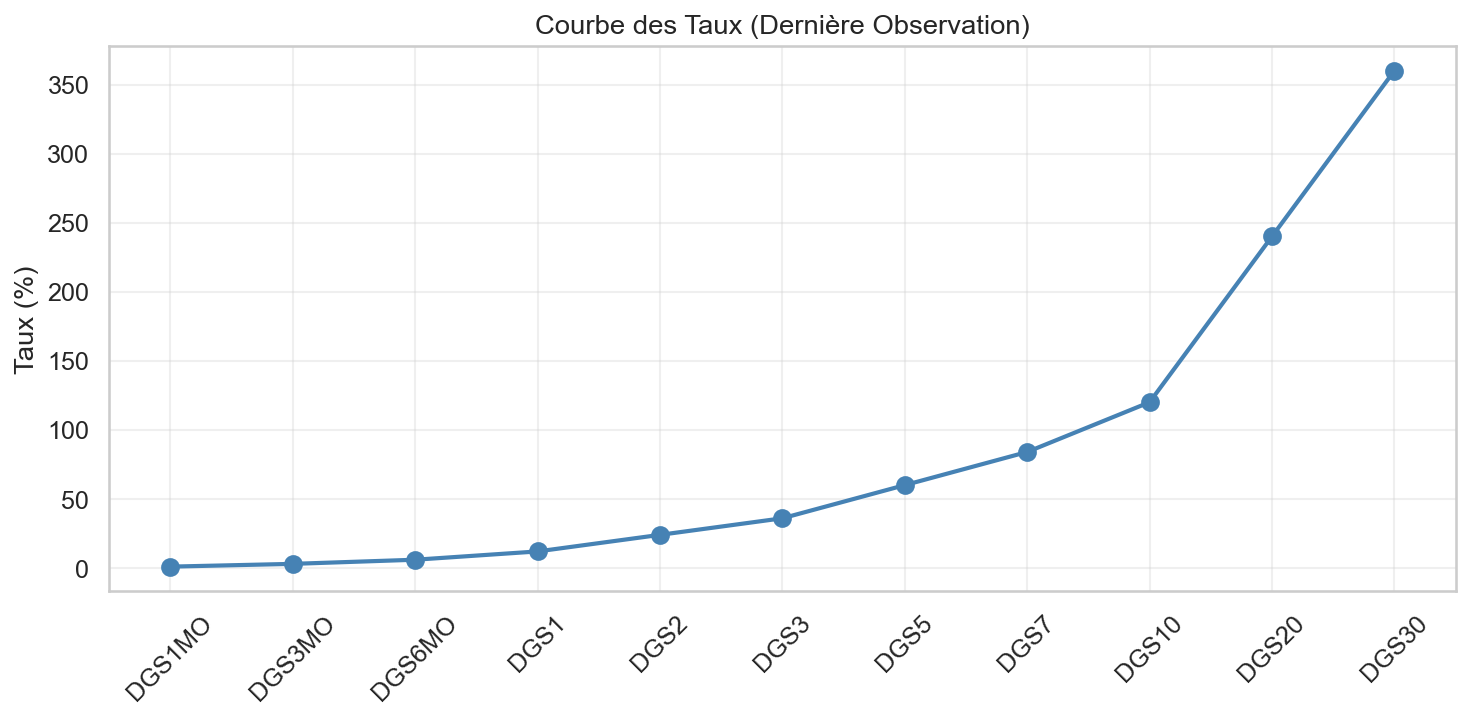

In [29]:
# ── Courbe des taux ───────────────────────────────────────────────────
yc_path = f"{DATA_ROOT}/raw/bonds/latest_yield_curve.csv"
if os.path.exists(yc_path):
    yc = pd.read_csv(yc_path)
    print(f"✅ Courbe des taux : {yc.shape}")
    print(yc.to_string())
    
    # Visualisation si possible
    # Essayer d'identifier les colonnes maturité / taux
    if yc.shape[1] >= 2:
        fig, ax = plt.subplots(figsize=(10, 5))
        if yc.shape[0] <= 15:  # Probablement maturities en lignes
            ax.plot(range(len(yc)), yc.iloc[:, -1] if yc.shape[1] > 1 else yc.iloc[:, 0], 
                    "o-", color="steelblue", linewidth=2, markersize=8)
            ax.set_xticks(range(len(yc)))
            ax.set_xticklabels(yc.iloc[:, 0] if yc.shape[1] > 1 else yc.index, rotation=45)
            ax.set_ylabel("Taux (%)")
            ax.set_title("Courbe des Taux (Dernière Observation)")
            ax.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.savefig("reports/figures/yield_curve_snapshot.png", dpi=150, bbox_inches="tight")
            plt.show()
else:
    print("❌ Courbe des taux non trouvée")

---
## 10. Bilan de Compatibilité avec la Problématique

Récapitulons la couverture de nos données par rapport aux besoins du système de recommandation.

In [30]:
# ── Tableau de compatibilité ───────────────────────────────────────────
compatibility = {
    "Composante du Système": [
        "Classification des actifs (6 classes)",
        "10 méthodes de valorisation cibles",
        "Features structurelles (14 features)",
        "Variable cible labellisée",
        "Données de marché (prix, volume)",
        "Données de volatilité (historique + implicite)",
        "Données de taux d'intérêt (FRED)",
        "Données de crédit (spreads)",
        "Données d'options (Greeks, IV)",
        "Données matières premières",
        "Données forex",
        "Hiérarchie IFRS 13 (Levels 1-2-3)",
        "Référence Hull (cadre théorique)",
    ],
    "Statut": [],
    "Commentaire": [],
}

# Vérifications automatiques
checks = [
    (df["asset_class"].nunique() >= 6, f"{df['asset_class'].nunique()} classes trouvées"),
    (df["recommended_method"].nunique() >= 10, f"{df['recommended_method'].nunique()} méthodes trouvées"),
    (len([c for c in required_fields if c in df.columns and c != "recommended_method"]) >= 12,
     f"{len([c for c in required_fields if c in df.columns]) - 1} features présentes"),
    ("recommended_method" in df.columns and df["recommended_method"].notnull().all(),
     f"{df['recommended_method'].notnull().sum()} labels, 0 manquants"),
    (os.path.exists(f"{DATA_ROOT}/raw/equities/equity_historical_prices.parquet"), "Parquet disponible"),
    (os.path.exists(f"{DATA_ROOT}/raw/options/options_chains_full.parquet"), "IV + Greeks disponibles"),
    (os.path.exists(f"{DATA_ROOT}/raw/macro/fred_treasury_yields.parquet"), "11 maturités"),
    (os.path.exists(f"{DATA_ROOT}/raw/macro/fred_credit_spreads.parquet"), "IG OAS, HY OAS, Baa-Aaa"),
    (os.path.exists(f"{DATA_ROOT}/raw/options/options_chains_full.parquet"), "Chaînes complètes"),
    (os.path.exists(f"{DATA_ROOT}/raw/commodities/commodity_prices.parquet"), "15 instruments"),
    (os.path.exists(f"{DATA_ROOT}/raw/forex/forex_prices.parquet"), "11 paires"),
    ("ifrs_level" in df.columns and set(df["ifrs_level"].unique()) == {1, 2, 3}, "Levels 1, 2, 3 couverts"),
    (True, "Hull + IFRS 13 encodés dans les règles expertes"),
]

for (ok, comment) in checks:
    compatibility["Statut"].append("✅ Prêt" if ok else "⚠️ À vérifier")
    compatibility["Commentaire"].append(comment)

compat_df = pd.DataFrame(compatibility)
print("\n📋 BILAN DE COMPATIBILITÉ AVEC LA PROBLÉMATIQUE")
print("=" * 80)
print(compat_df.to_string(index=False))

n_ready = sum(1 for s in compatibility["Statut"] if "✅" in s)
n_total = len(compatibility["Statut"])
print(f"\n📊 Score : {n_ready}/{n_total} composantes prêtes")


📋 BILAN DE COMPATIBILITÉ AVEC LA PROBLÉMATIQUE
                         Composante du Système Statut                                     Commentaire
         Classification des actifs (6 classes) ✅ Prêt                              7 classes trouvées
            10 méthodes de valorisation cibles ✅ Prêt                            10 méthodes trouvées
          Features structurelles (14 features) ✅ Prêt                           14 features présentes
                     Variable cible labellisée ✅ Prêt                        4150 labels, 0 manquants
              Données de marché (prix, volume) ✅ Prêt                              Parquet disponible
Données de volatilité (historique + implicite) ✅ Prêt                         IV + Greeks disponibles
              Données de taux d'intérêt (FRED) ✅ Prêt                                    11 maturités
                   Données de crédit (spreads) ✅ Prêt                         IG OAS, HY OAS, Baa-Aaa
                Données d'options 

---
## 11. Tableau de Synthèse (pour le Rapport — Chapitre 3)

Ce tableau résume les statistiques clés à inclure dans la section 3.2 du rapport LaTeX.

In [31]:
# ── Tableau de synthèse pour le rapport ────────────────────────────────
def safe_load(path, loader="parquet"):
    if not os.path.exists(path):
        return None
    try:
        if loader == "parquet":
            return pd.read_parquet(path)
        else:
            return pd.read_csv(path, low_memory=False)
    except:
        return None

catalog_df = safe_load(f"{DATA_ROOT}/catalogs/full_instrument_catalog.csv", "csv")
options_df = safe_load(f"{DATA_ROOT}/raw/options/options_chains_full.parquet")
eq_fund_df = safe_load(f"{DATA_ROOT}/raw/equities/equity_fundamentals.parquet")

summary = {
    "Métrique": [
        "Instruments dans le catalogue",
        "Échantillons d'entraînement labellisés",
        "Nombre de features",
        "Nombre de classes cibles",
        "Classe majoritaire",
        "Classe minoritaire",
        "Ratio d'imbalance",
        "Valeurs manquantes (maturity_years)",
        "Tickers actions avec fondamentaux",
        "Contrats d'options collectés",
        "Séries FRED collectées",
        "Maturités courbe des taux",
        "Paires forex",
        "Instruments commodités",
    ],
    "Valeur": [
        f"{len(catalog_df):,}" if catalog_df is not None else "N/A",
        f"{len(df):,}",
        str(len(df.columns) - 1),
        str(df["recommended_method"].nunique()),
        f"{df['recommended_method'].value_counts().idxmax()} ({df['recommended_method'].value_counts().max()})",
        f"{df['recommended_method'].value_counts().idxmin()} ({df['recommended_method'].value_counts().min()})",
        f"{df['recommended_method'].value_counts().max() / df['recommended_method'].value_counts().min():.1f}:1",
        f"{df['maturity_years'].isnull().sum()} ({df['maturity_years'].isnull().mean()*100:.1f}%)",
        str(len(eq_fund_df)) if eq_fund_df is not None else "N/A",
        f"{len(options_df):,}" if options_df is not None else "N/A",
        "28",
        "11",
        "11",
        "15",
    ]
}

summary_df = pd.DataFrame(summary)
print("\n" + "=" * 60)
print("   TABLEAU DE SYNTHÈSE — EDA")
print("=" * 60)
print(summary_df.to_string(index=False))

# Sauvegarder pour le rapport
summary_df.to_csv("reports/eda_summary.csv", index=False)
print("\n📁 Tableau sauvegardé : reports/eda_summary.csv")


   TABLEAU DE SYNTHÈSE — EDA
                              Métrique         Valeur
         Instruments dans le catalogue        353,749
Échantillons d'entraînement labellisés          4,150
                    Nombre de features             14
              Nombre de classes cibles             10
                    Classe majoritaire     DCF (1061)
                    Classe minoritaire Relative (243)
                     Ratio d'imbalance          4.4:1
   Valeurs manquantes (maturity_years)   1100 (26.5%)
     Tickers actions avec fondamentaux             50
          Contrats d'options collectés         18,883
                Séries FRED collectées             28
             Maturités courbe des taux             11
                          Paires forex             11
                Instruments commodités             15

📁 Tableau sauvegardé : reports/eda_summary.csv


---
## 12. Conclusions et Actions pour la Phase Suivante

### ✅ Points validés
1. **Complétude des données** : tous les fichiers de la collecte sont présents et lisibles
2. **Cohérence financière** : les mappings asset_class → méthode respectent le cadre théorique de Hull et IFRS 13
3. **Structure du dataset** : les 14 features structurelles et la variable cible sont correctement définies
4. **Couverture** : les 6 classes d'actifs et 10 méthodes de valorisation sont représentées
5. **Hiérarchie IFRS 13** : les 3 niveaux sont présents avec les contraintes appropriées

### ⚠️ Points d'attention
- **Déséquilibre des classes** : ratio d'imbalance à surveiller → utiliser `class_weight="balanced"` ou SMOTE si nécessaire
- **Valeurs NaN de maturity** : normal pour les actifs perpétuels → sentinel -1 pour les modèles à base d'arbres
- **Données réelles** : vérifier la qualité des IV (options), des taux (FRED) et des fondamentaux avant l'enrichissement

### 🔜 Prochaine étape : Phase 2 — Feature Engineering
1. Calculer les features dérivées (volatilité, Greeks, taux) à partir des données réelles
2. Enrichir le dataset synthétique avec des valeurs numériques réalistes
3. Encoder les variables catégorielles et ordinales
4. Traiter les valeurs manquantes
5. Produire `features_final.parquet` prêt pour l'entraînement

In [32]:
print("\n" + "=" * 60)
print("   ✅ NOTEBOOK EDA TERMINÉ")
print("=" * 60)
print("\n📁 Figures sauvegardées dans : reports/figures/")
print("📁 Synthèse sauvegardée dans : reports/eda_summary.csv")
print("\n🔜 Prochaine étape : 03_feature_engineering.ipynb")


   ✅ NOTEBOOK EDA TERMINÉ

📁 Figures sauvegardées dans : reports/figures/
📁 Synthèse sauvegardée dans : reports/eda_summary.csv

🔜 Prochaine étape : 03_feature_engineering.ipynb
